In [1]:
import pandas as pd

In [2]:
# https://www.kaggle.com/datasets/nirmalgaud/customer-complaints-ticket-classification

# https://www.kaggle.com/datasets/aniketg11/supportticketsclassification

In [3]:
df = pd.read_csv("customer_support_tickets.csv")
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
# prompt: calculate time taken to solve the issue using First Response Time (start time), Time to Resolution (end time), and put it in bins of 5 hours

import pandas as pd

# Assuming your DataFrame is named 'df' and contains columns 'First Response Time' and 'Time to Resolution'
# Replace 'First Response Time' and 'Time to Resolution' with your actual column names if they are different.

# Convert time columns to datetime objects if they are not already
df['First Response Time'] = pd.to_datetime(df['First Response Time'])
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'])

# Calculate the time taken to solve the issue
df['Time Taken'] = (df['Time to Resolution'] - df['First Response Time']).dt.total_seconds() / 3600  # Time difference in hours

# Create bins of 5 hours
bins = range(0, int(df['Time Taken'].max()) + 6, 5)  # Create bins up to the maximum time taken, with 5-hour intervals

# Use pd.cut to categorize the time taken into bins
df['Time Taken Bins'] = pd.cut(df['Time Taken'], bins=bins, right=False)

# Print the DataFrame with the new 'Time Taken Bins' column
df

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Time Taken,Time Taken Bins
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,6.850000,"[5.0, 10.0)"
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,-5.533333,NaN
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,19.683333,"[15.0, 20.0)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaT,NaT,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaT,NaT,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0,-5.216667,NaN
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0,-12.933333,NaN


In [5]:
df["Time Taken Bins"].value_counts()

Time Taken Bins
[0, 5)      582
[5, 10)     397
[10, 15)    240
[15, 20)    156
[20, 25)     29
Name: count, dtype: int64

In [6]:
df.loc[df["Time Taken Bins"].map(str).eq("[20, 25)"), :]

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Time Taken,Time Taken Bins
418,419,Kara Wright PhD,dawnmartinez@example.net,47,Female,Garmin Forerunner,2020-06-17,Technical issue,Software bug,I'm having an issue with the {product_purchase...,Closed,It professor television little director discus...,Low,Chat,2023-05-31 22:20:10,2023-06-01 20:41:10,2.0,22.350000,"[20, 25)"
755,756,Holly Thomas,jennifer65@example.net,26,Other,Philips Hue Lights,2020-10-06,Refund request,Installation support,I'm having trouble connecting my {product_purc...,Closed,Represent focus middle.,High,Chat,2023-05-31 23:58:02,2023-06-01 20:38:02,2.0,20.666667,"[20, 25)"
815,816,Dr. Sarah Gardner,nicholasclements@example.net,27,Other,Nintendo Switch Pro Controller,2021-04-11,Product inquiry,Hardware issue,I'm having an issue with the {product_purchase...,Closed,Product thought own walk six money.,Low,Social media,2023-06-01 00:42:26,2023-06-01 21:50:26,4.0,21.133333,"[20, 25)"
1239,1240,John Solis,neilpeters@example.com,19,Other,Bose SoundLink Speaker,2020-02-25,Cancellation request,Network problem,I'm encountering a software bug in the {produc...,Closed,Start spend from.,Critical,Email,2023-06-01 01:08:12,2023-06-01 21:48:12,1.0,20.666667,"[20, 25)"
1764,1765,Erica Scott DVM,millsdenise@example.net,40,Female,Microsoft Xbox Controller,2021-02-21,Refund request,Peripheral compatibility,I've forgotten my password for my {product_pur...,Closed,Quite article doctor hair should fine boy.,Low,Chat,2023-06-01 01:26:03,2023-06-01 22:11:03,2.0,20.750000,"[20, 25)"
1838,1839,Tina Brown,mary24@example.com,18,Other,HP Pavilion,2020-08-22,Refund request,Software bug,I'm having an issue with the {product_purchase...,Closed,Turn direction rule kitchen strong health.,Low,Chat,2023-05-31 23:03:45,2023-06-01 21:25:45,4.0,22.366667,"[20, 25)"
2648,2649,Lauren White,hclark@example.org,31,Female,Amazon Echo,2021-11-04,Billing inquiry,Hardware issue,I've forgotten my password for my {product_pur...,Closed,Care medical brother until.,Low,Social media,2023-05-31 23:25:48,2023-06-01 21:43:48,4.0,22.300000,"[20, 25)"
2715,2716,Joseph Brown,seanclark@example.org,27,Female,PlayStation,2020-08-01,Technical issue,Product recommendation,I'm having an issue with the {product_purchase...,Closed,Himself Congress population.,Low,Email,2023-05-31 23:04:19,2023-06-01 21:41:19,3.0,22.616667,"[20, 25)"
3008,3009,Kimberly Mercado,patrickwilliams@example.org,41,Female,PlayStation,2021-06-23,Refund request,Hardware issue,I'm having an issue with the {product_purchase...,Closed,Nation beautiful per economy project.,Low,Social media,2023-06-01 00:58:50,2023-06-01 21:41:50,5.0,20.716667,"[20, 25)"
3030,3031,William Stein,tthompson@example.net,29,Male,Amazon Echo,2020-11-17,Refund request,Product recommendation,I'm unable to access my {product_purchased} ac...,Closed,To economic however result strategy produce away.,High,Email,2023-05-31 23:13:23,2023-06-01 19:45:23,4.0,20.533333,"[20, 25)"


In [7]:
df.shape

(8469, 19)

In [8]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating', 'Time Taken', 'Time Taken Bins'],
      dtype='object')

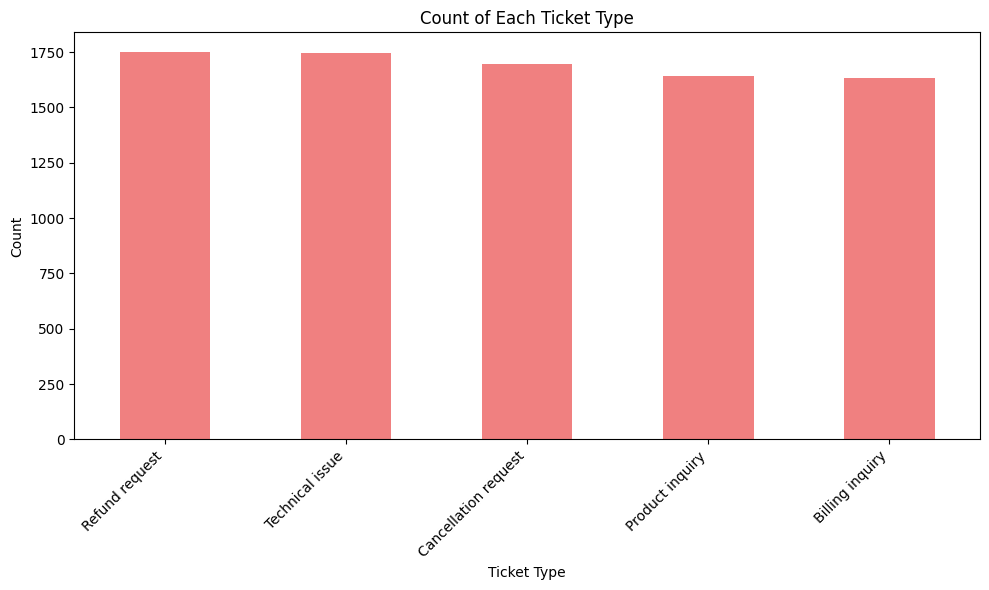

In [9]:
# prompt: count of each ticket type
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# Assuming 'df' is already loaded as in the previous code
# df = pd.read_csv("customer_support_tickets.csv")

Ticket_Type = df['Ticket Type'].unique()
Ticket_Type_Count = df['Ticket Type'].value_counts()

plt.figure(figsize=(10, 6))
Ticket_Type_Count.plot(kind='bar', color='lightcoral')
plt.xlabel('Ticket Type')
plt.ylabel('Count')
plt.title('Count of Each Ticket Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

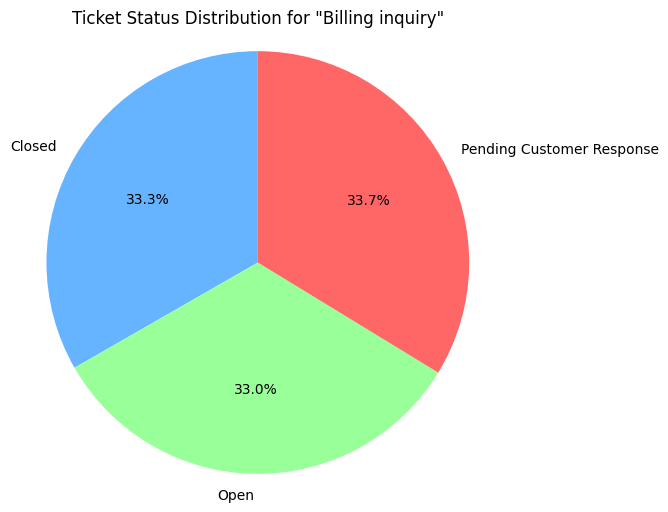

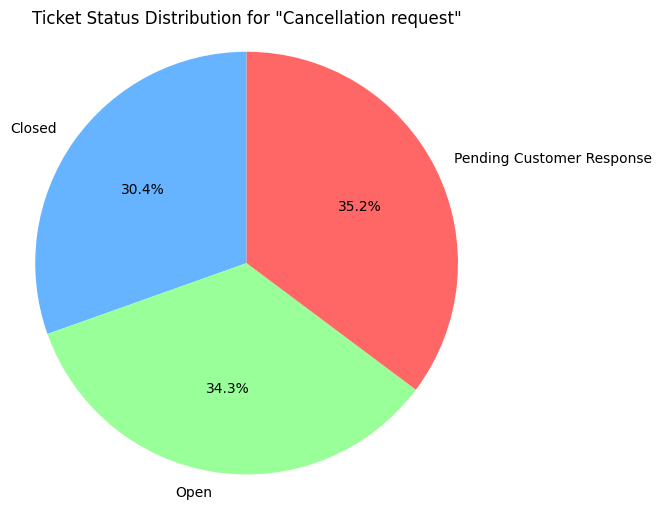

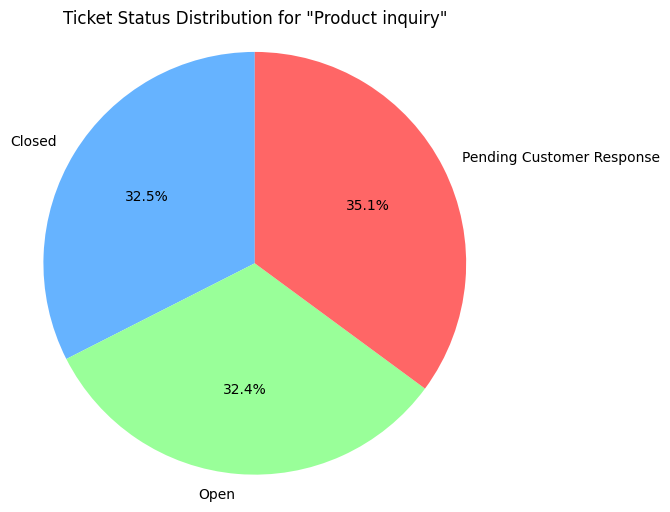

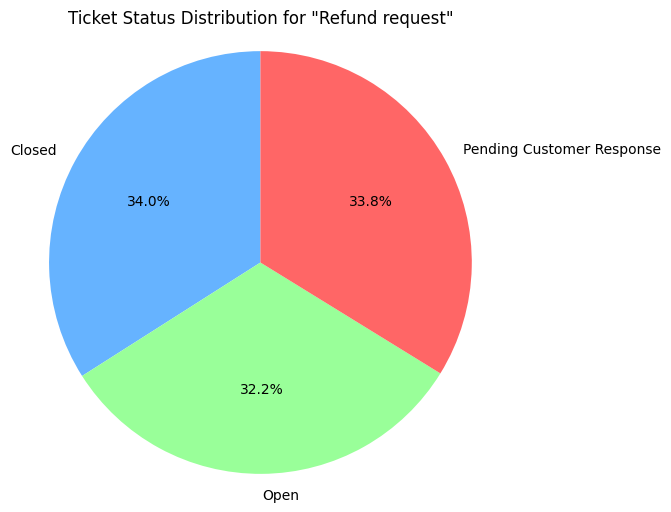

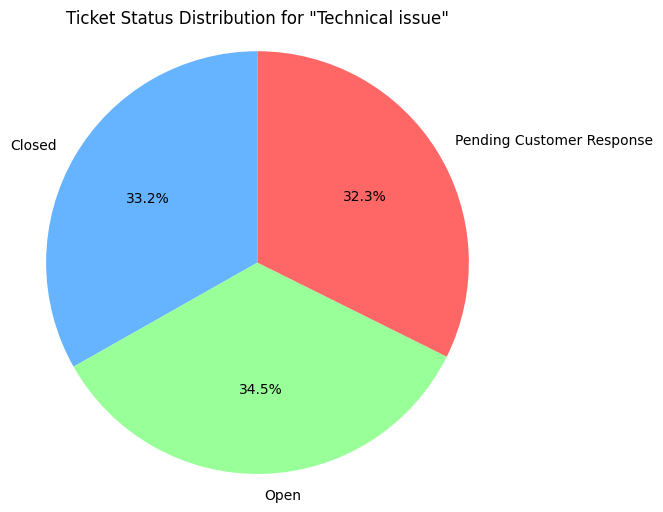

In [10]:
# prompt: Ticket status Distribution of each query issue

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is already loaded as in the previous code
# df = pd.read_csv("customer_support_tickets.csv")

Ticket_Status = df['Ticket Status'].unique()
ticket_status_counts = df.groupby('Ticket Type')['Ticket Status'].value_counts().unstack(fill_value=0)

for ticket_type in ticket_status_counts.index:
    plt.figure(figsize=(6, 6))
    status_counts = ticket_status_counts.loc[ticket_type]
    
    plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#99ff99', '#ff6666'])
    plt.title(f'Ticket Status Distribution for "{ticket_type}"')
    plt.axis('equal') 
    plt.show()

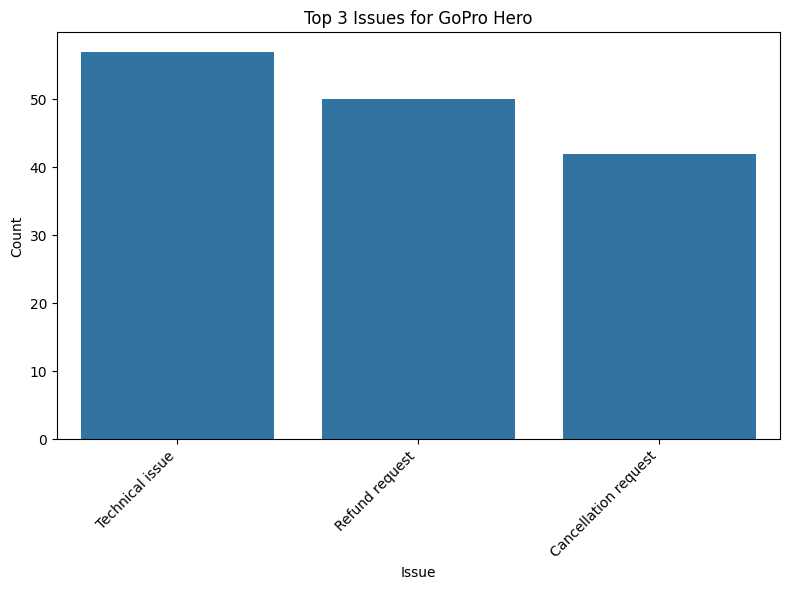

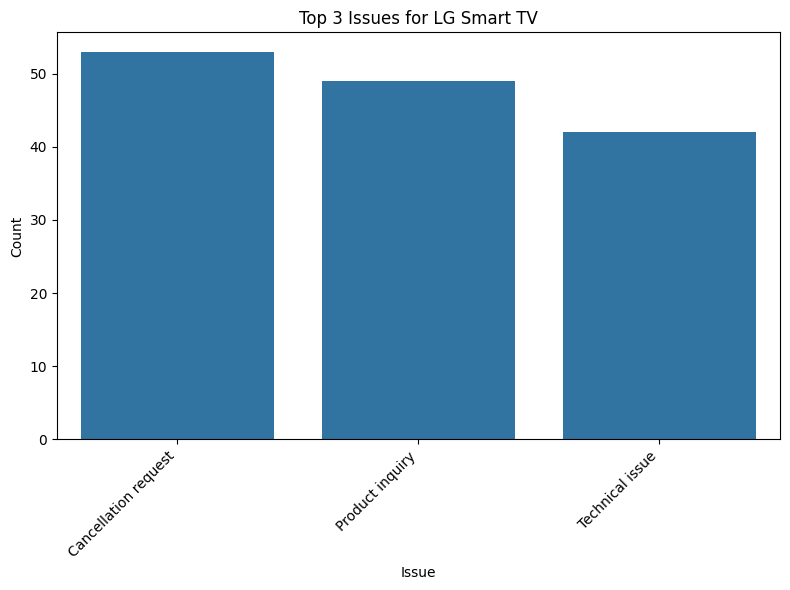

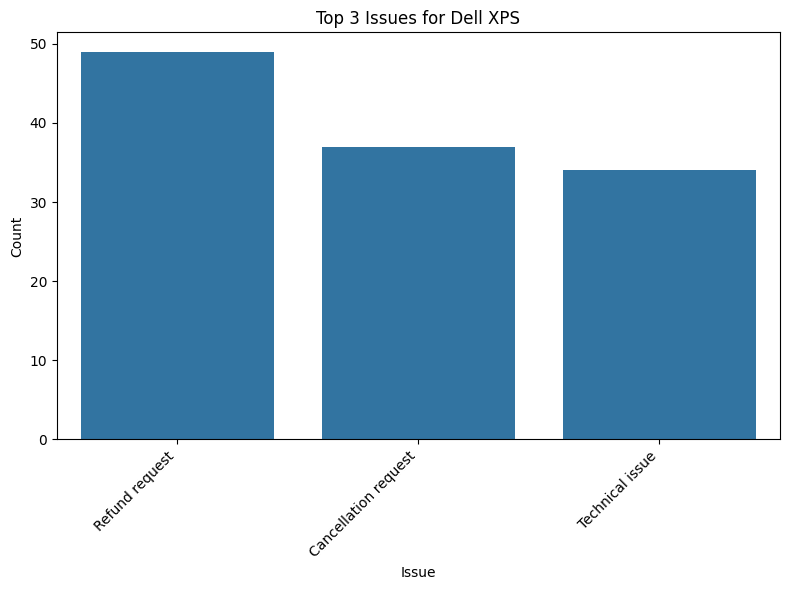

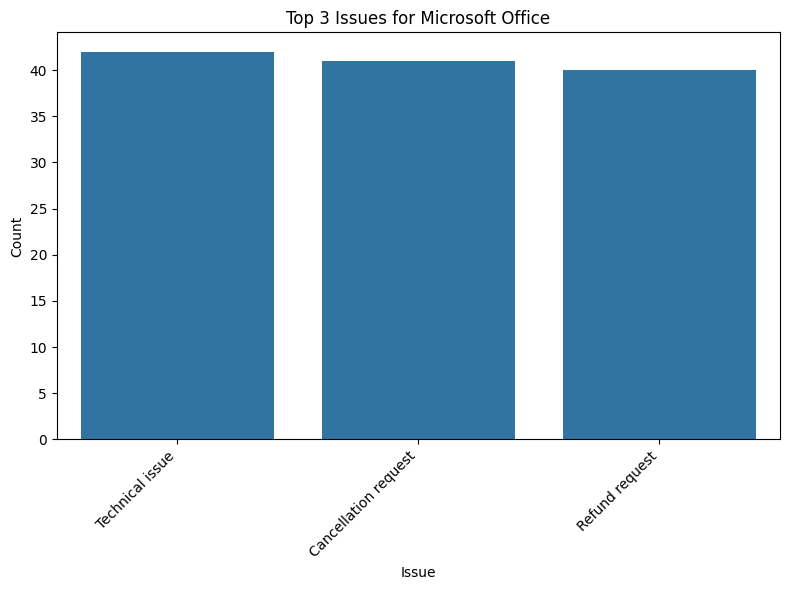

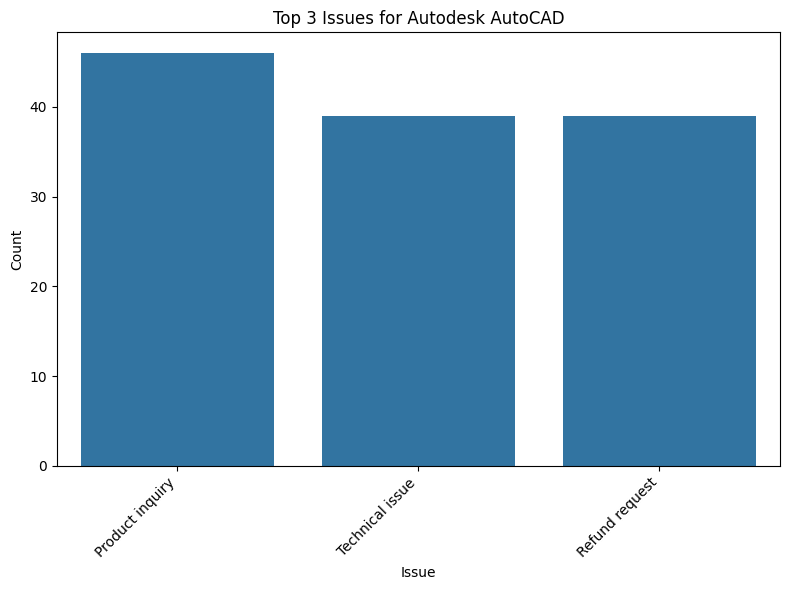

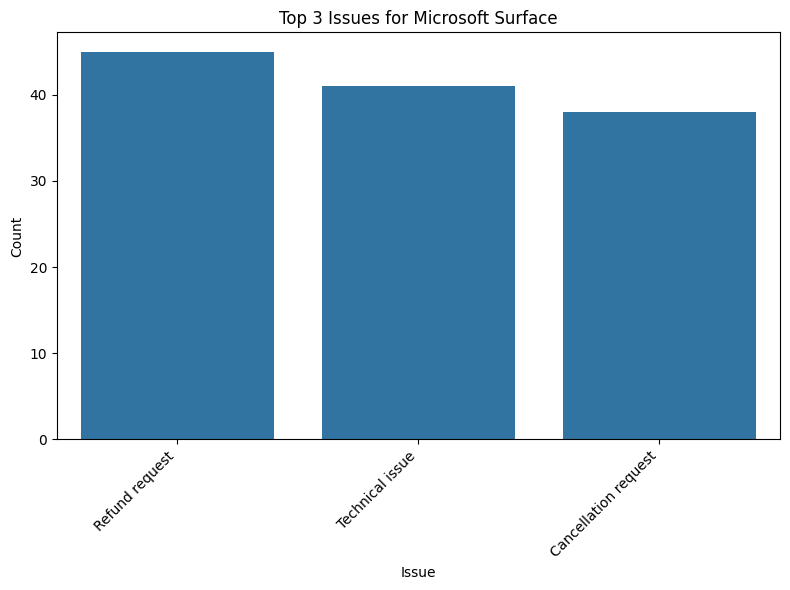

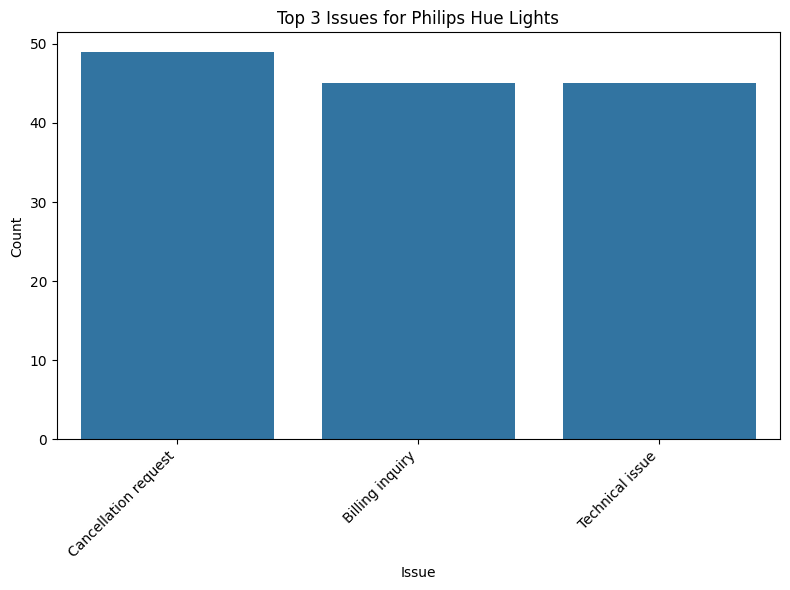

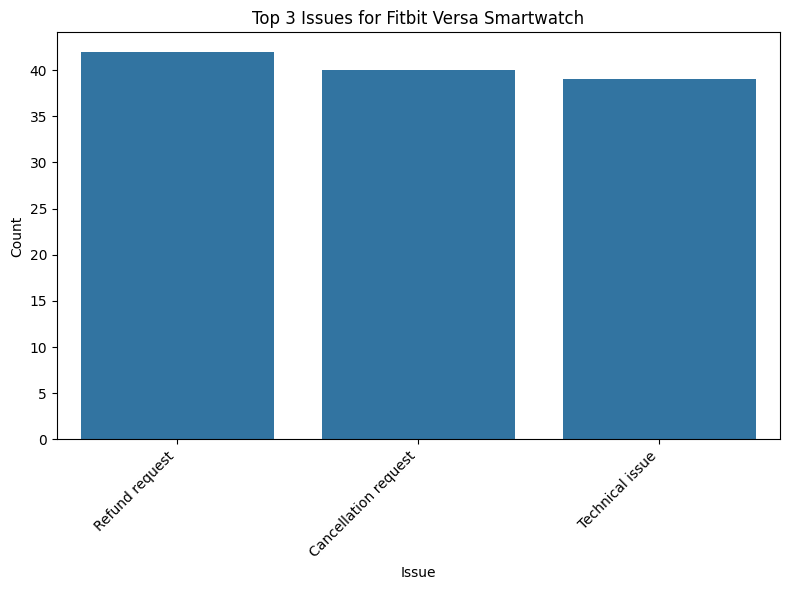

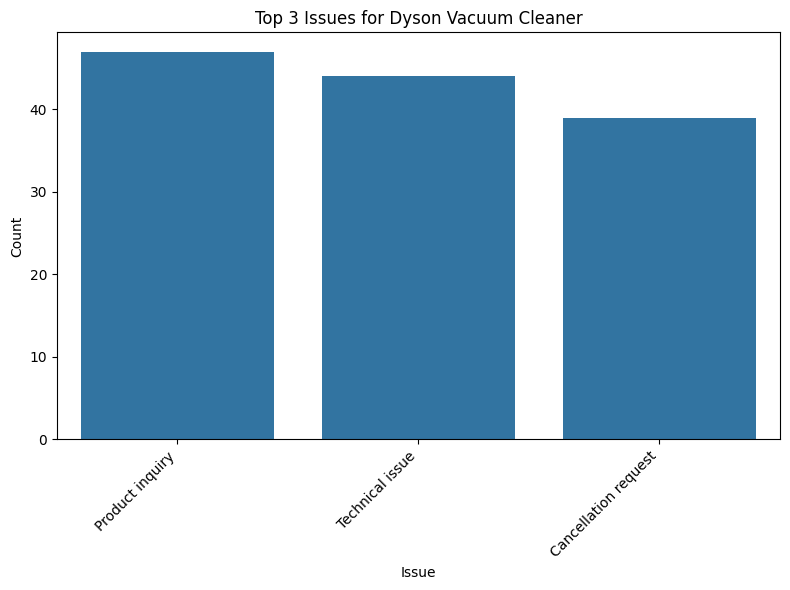

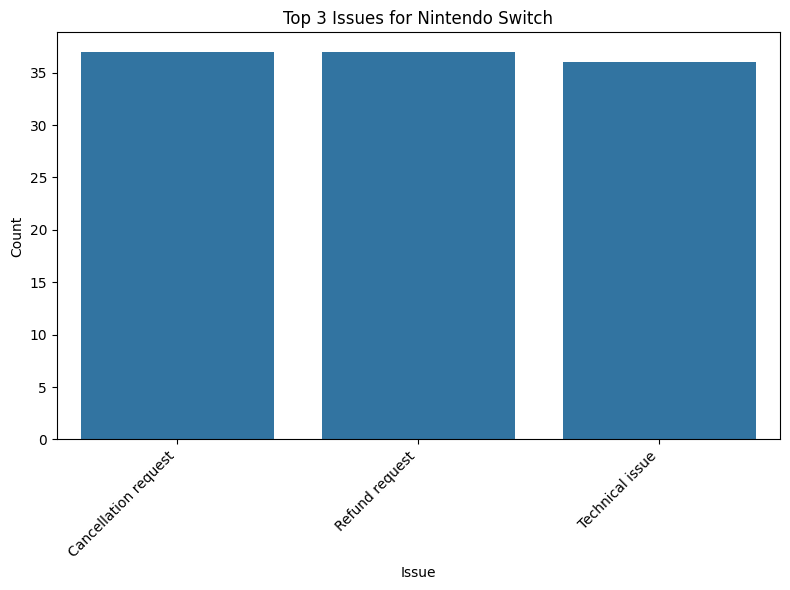

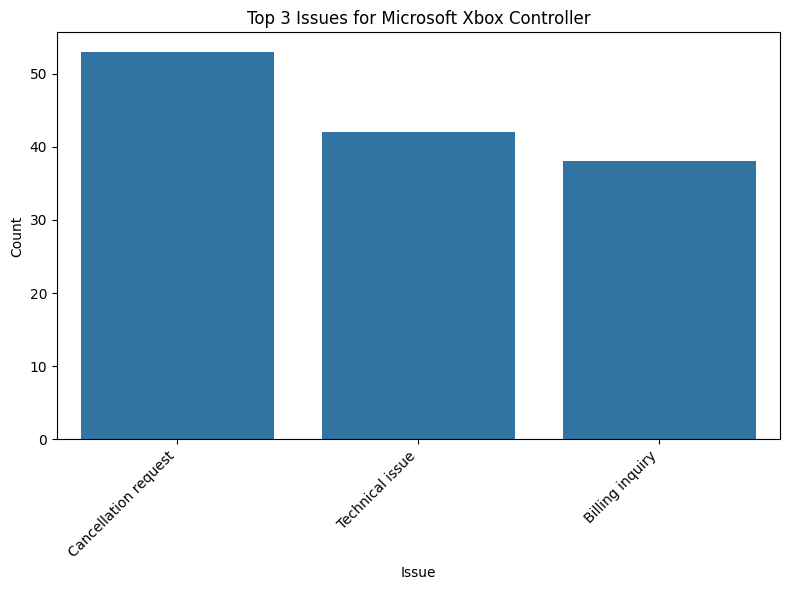

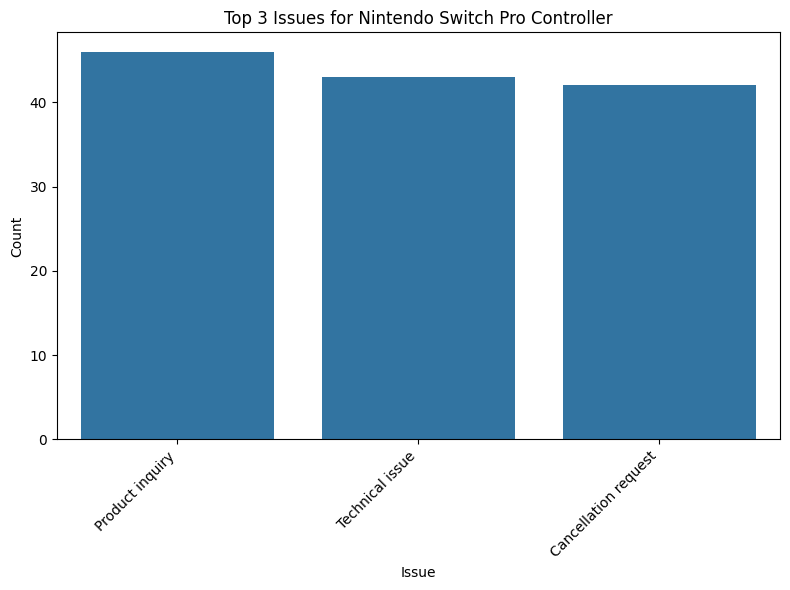

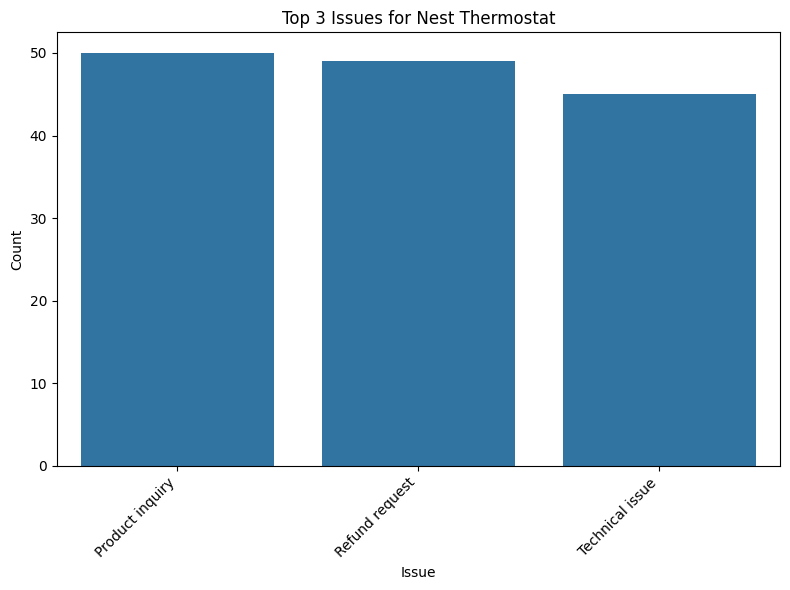

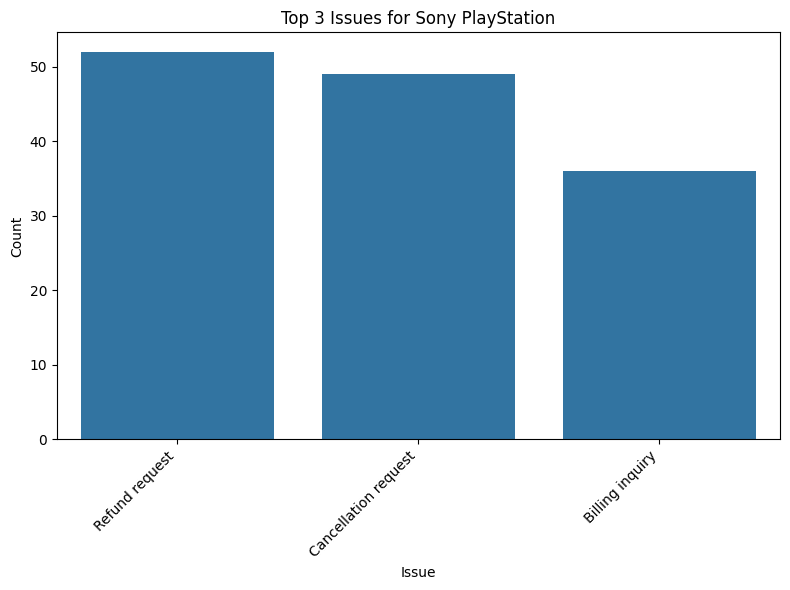

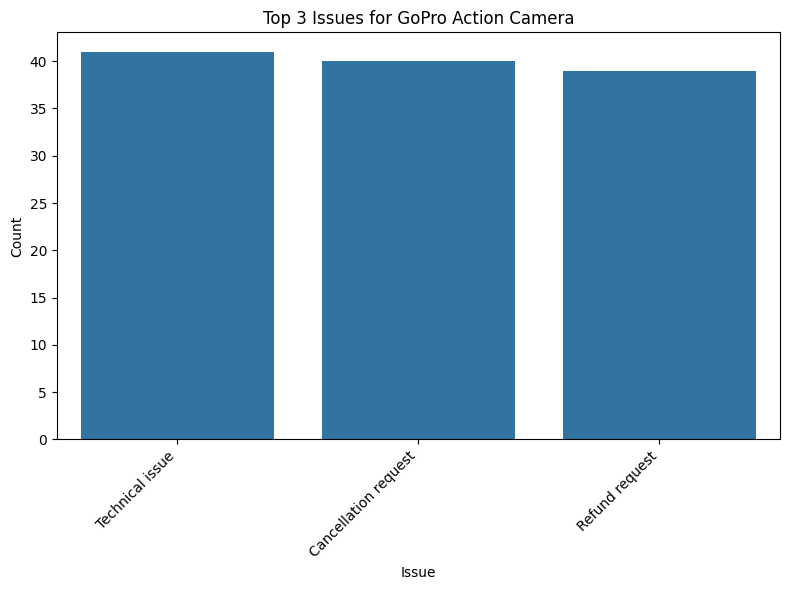

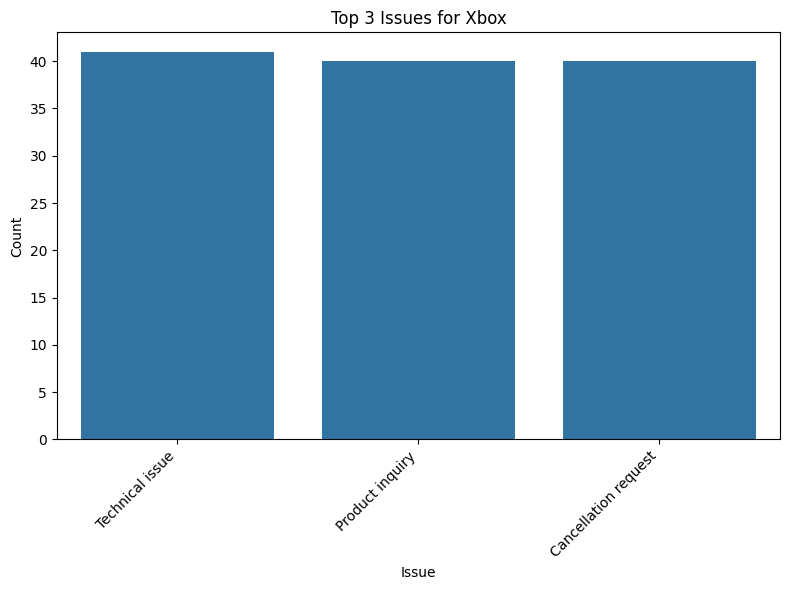

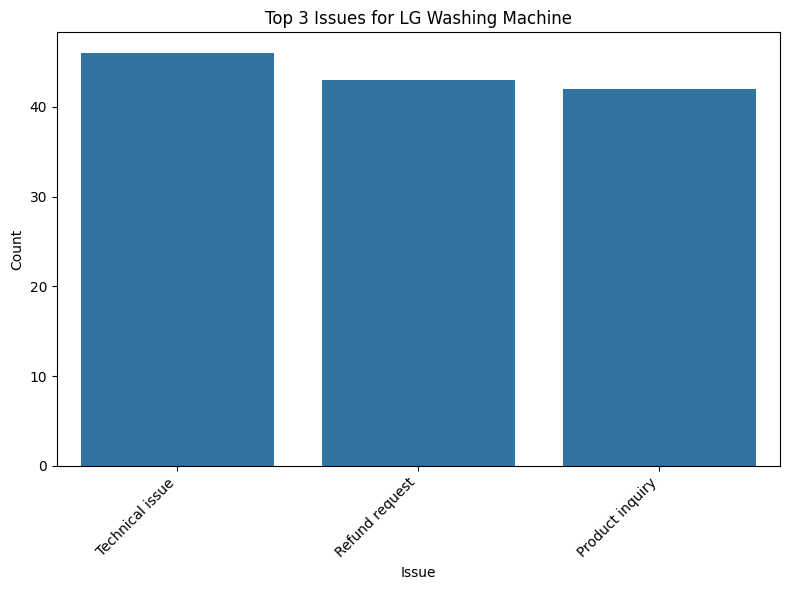

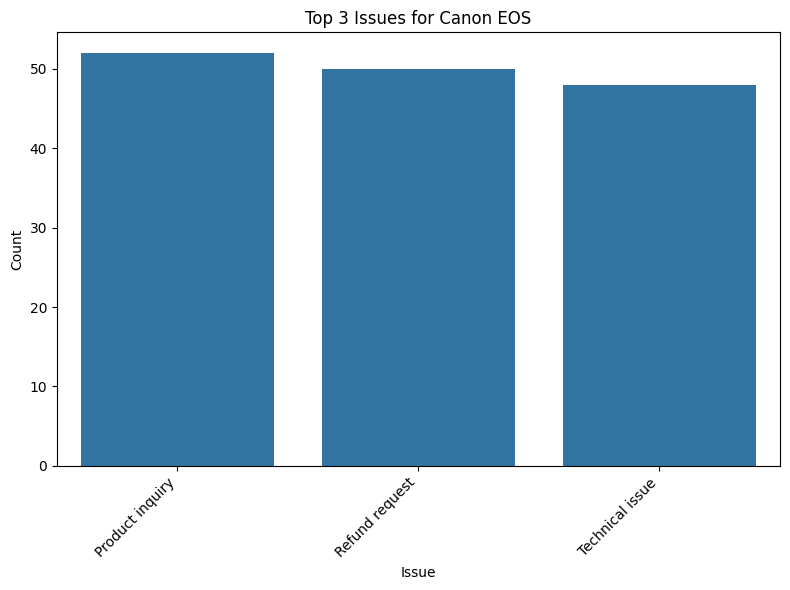

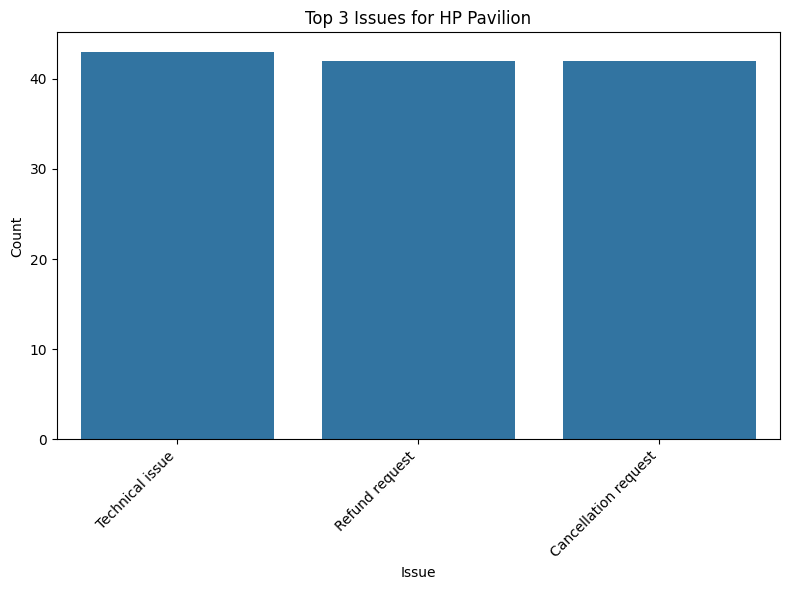

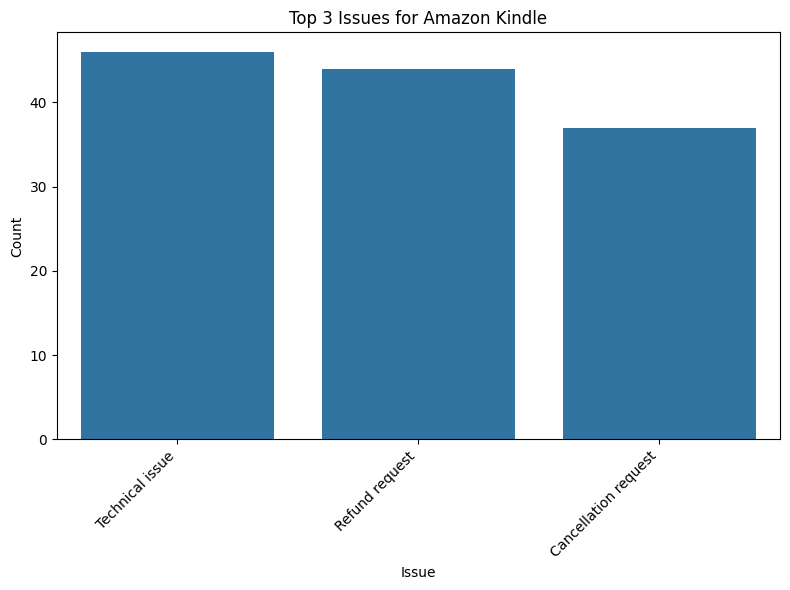

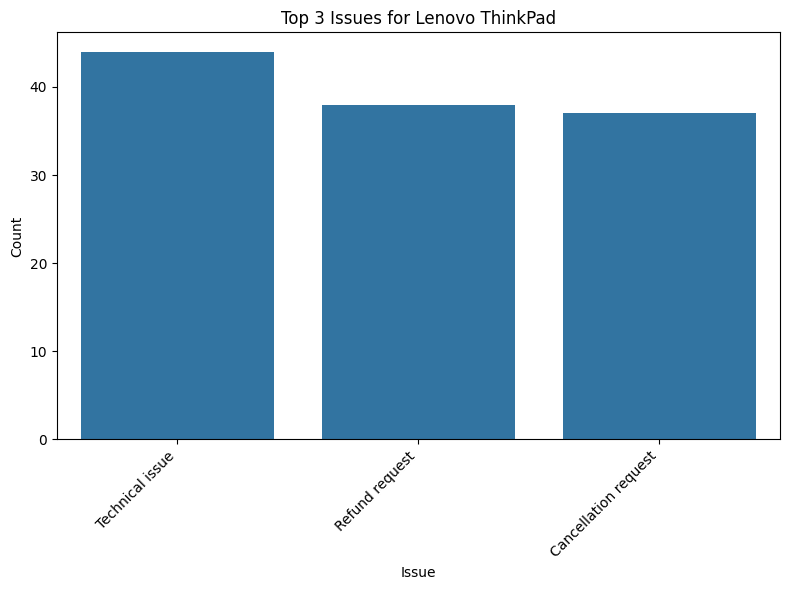

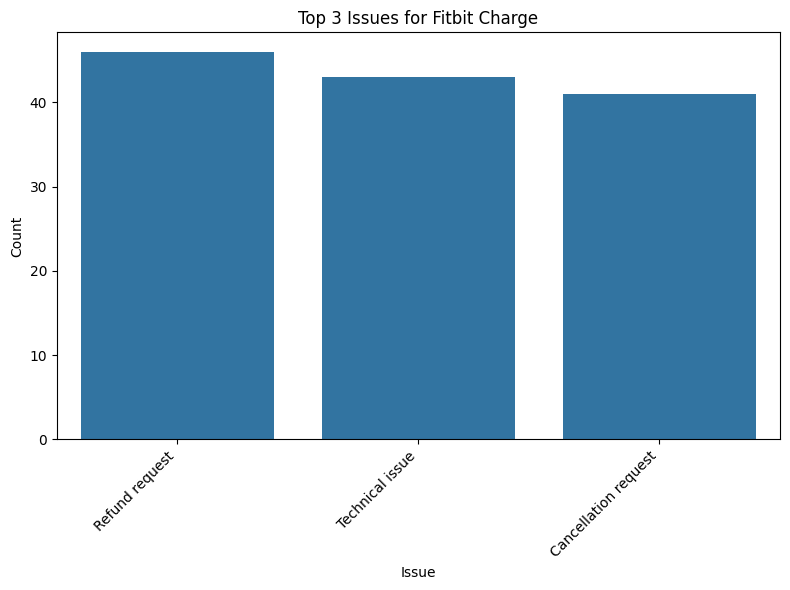

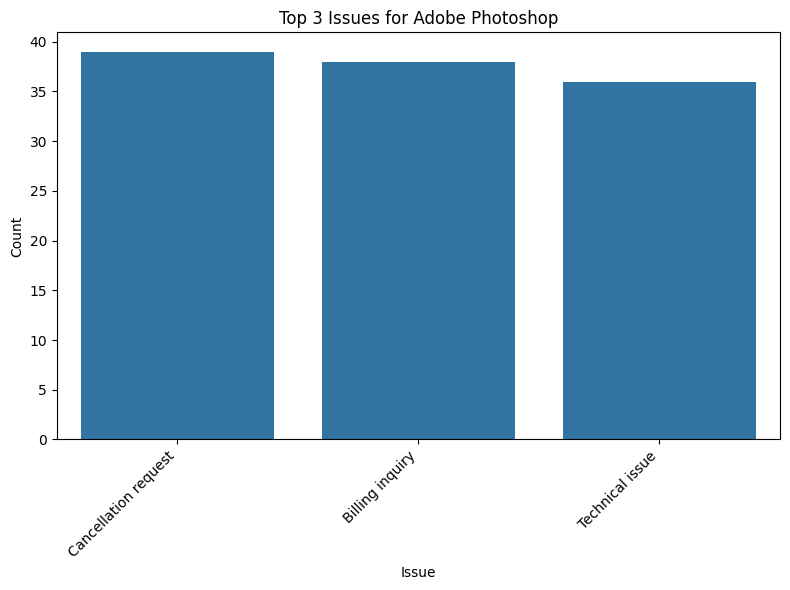

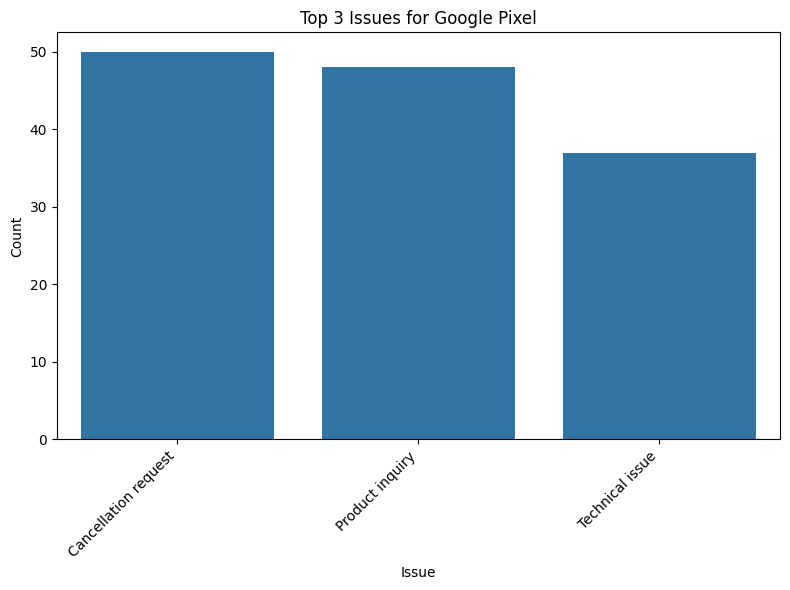

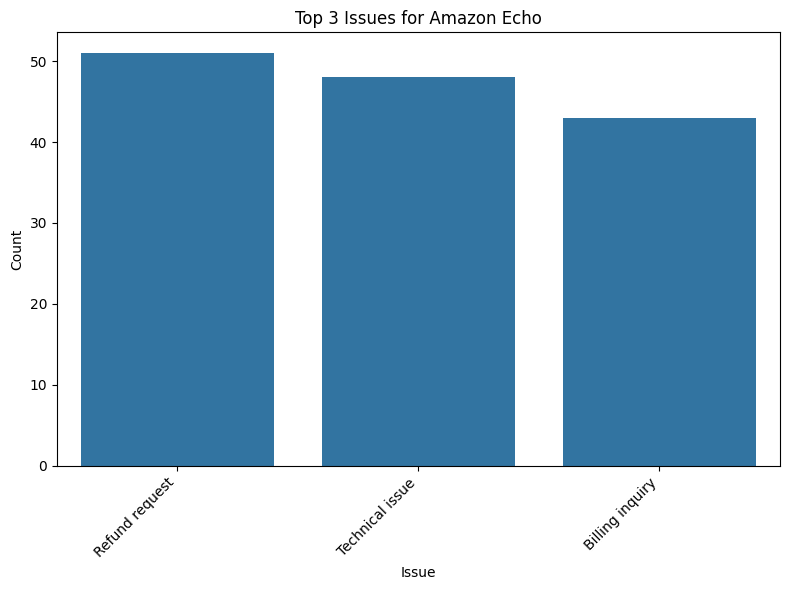

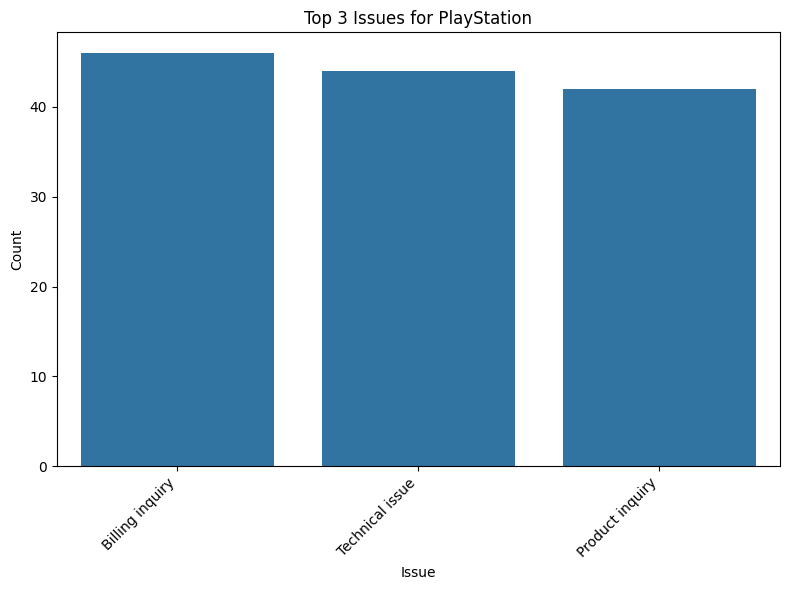

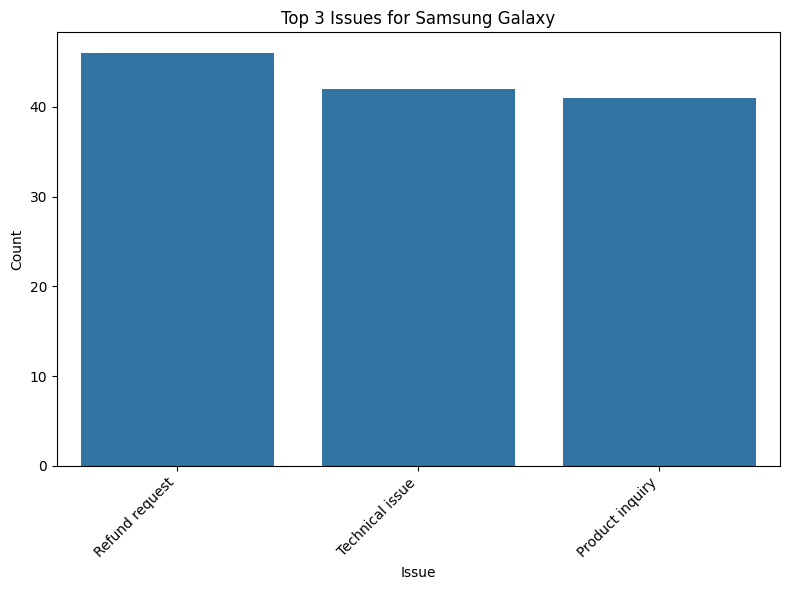

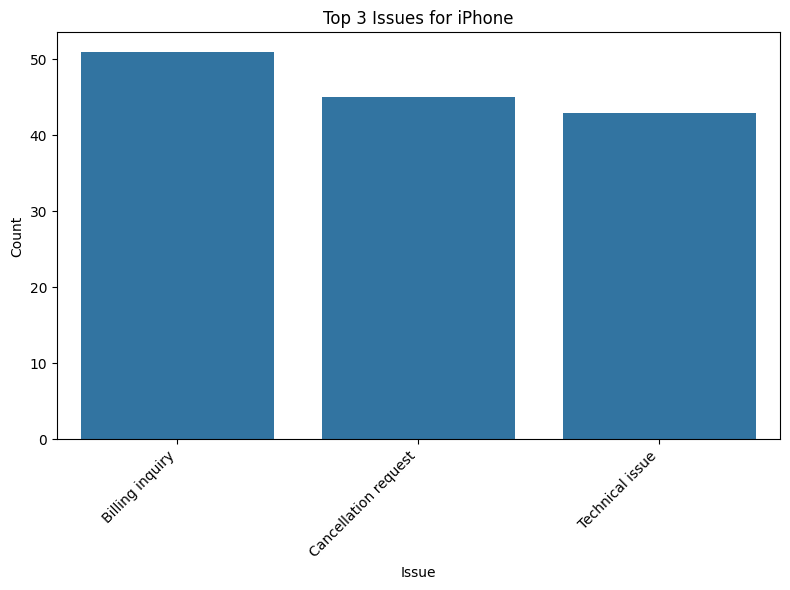

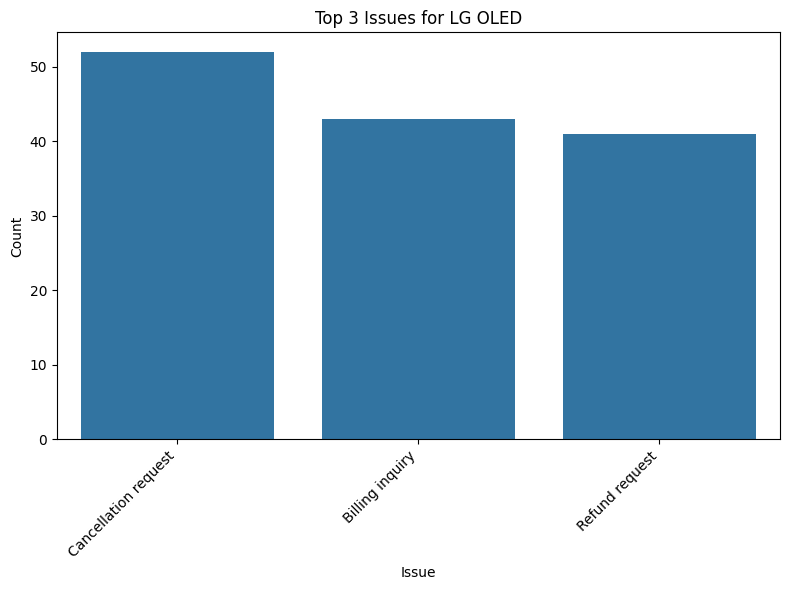

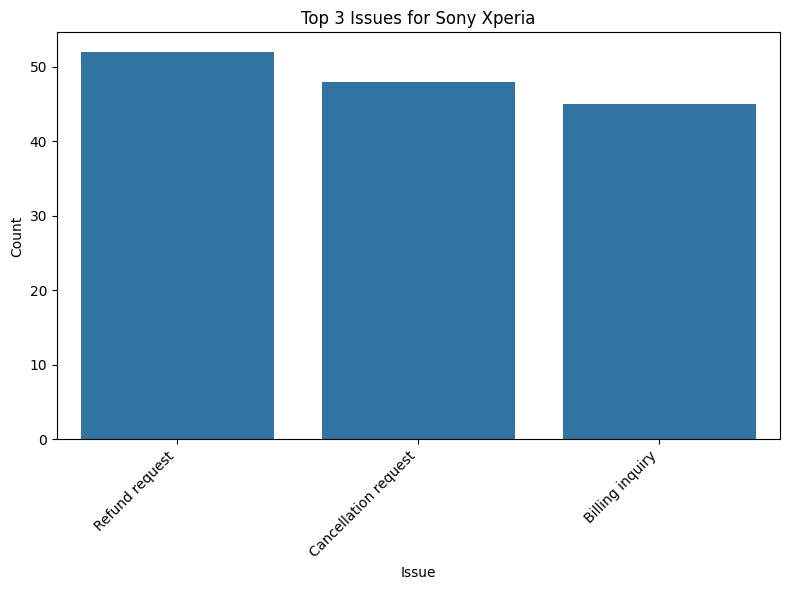

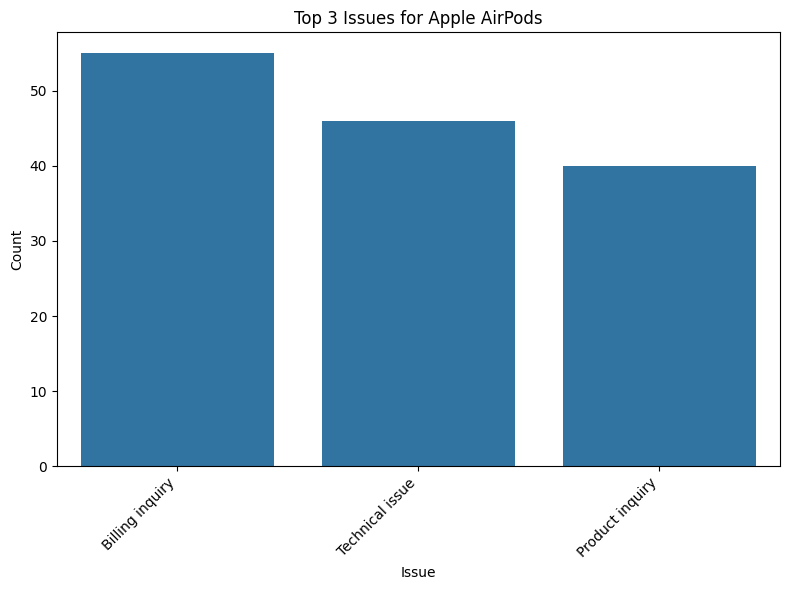

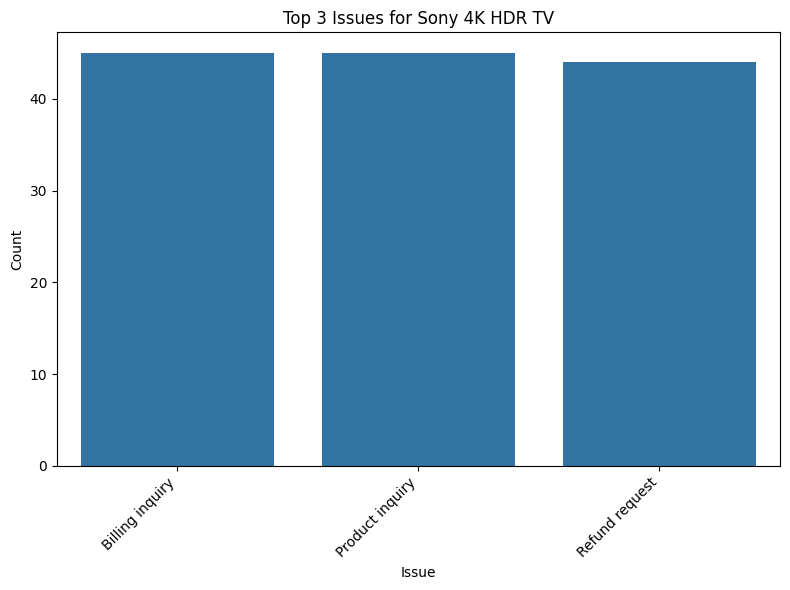

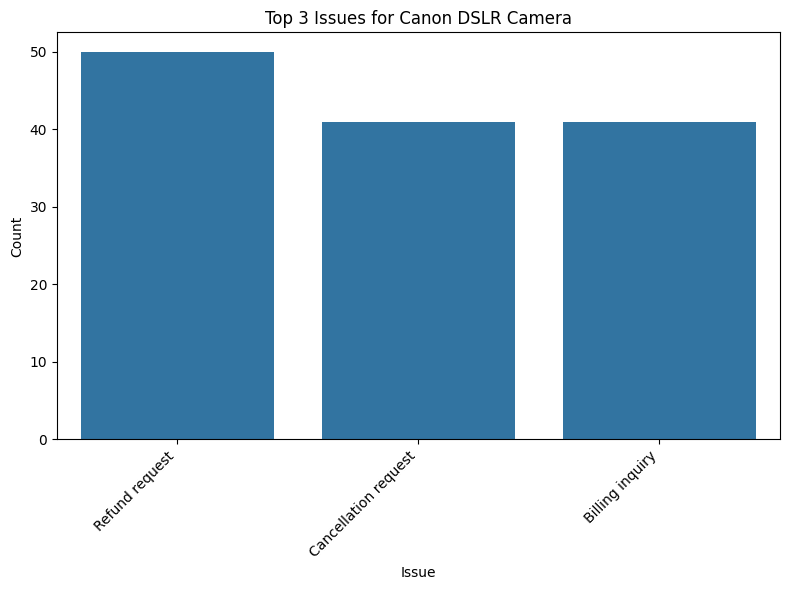

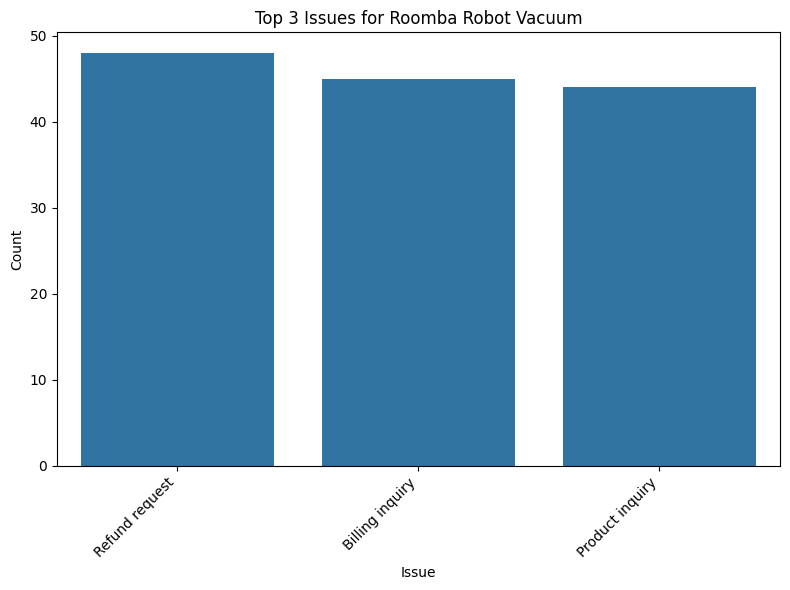

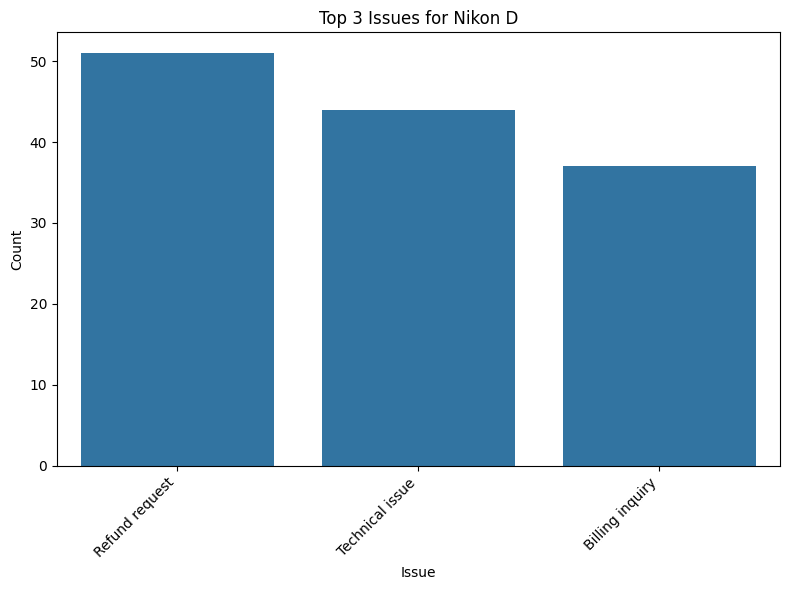

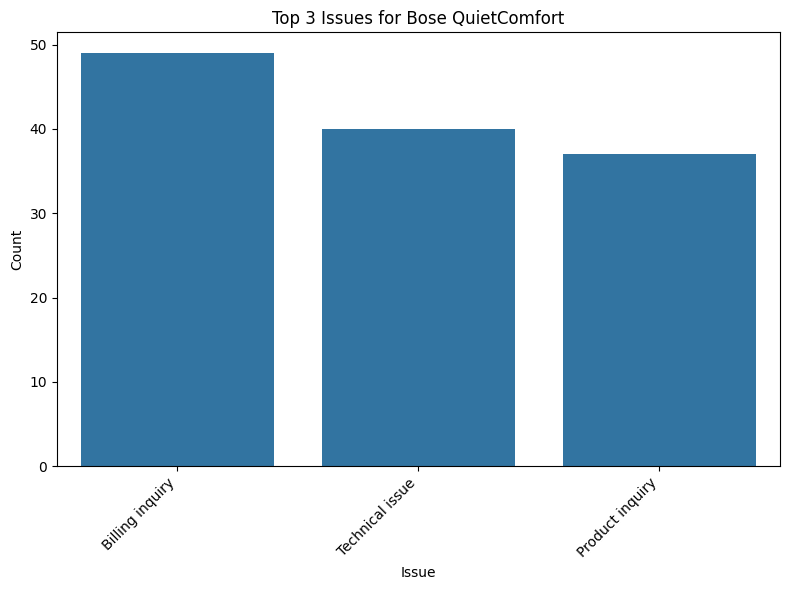

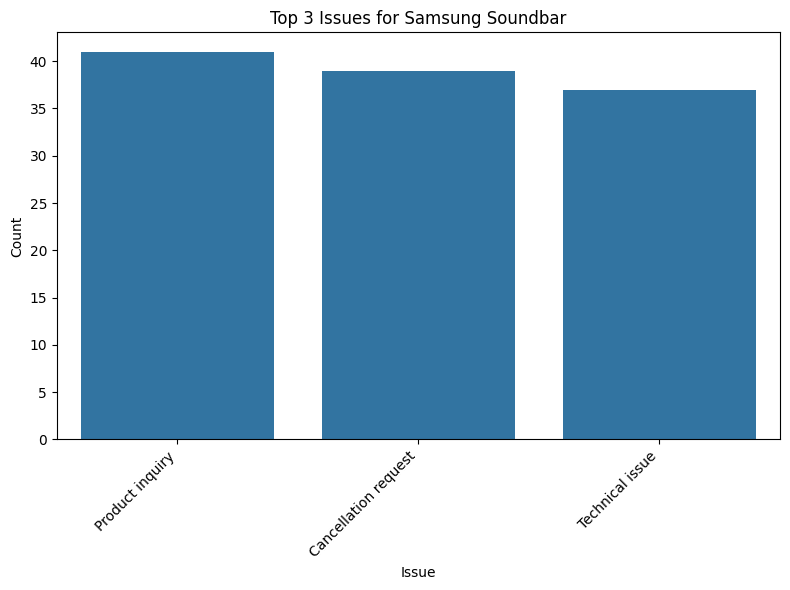

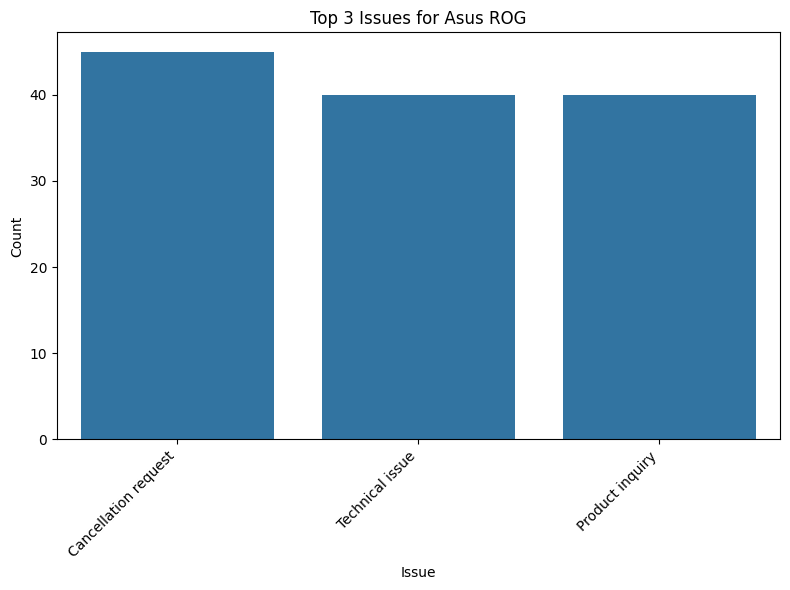

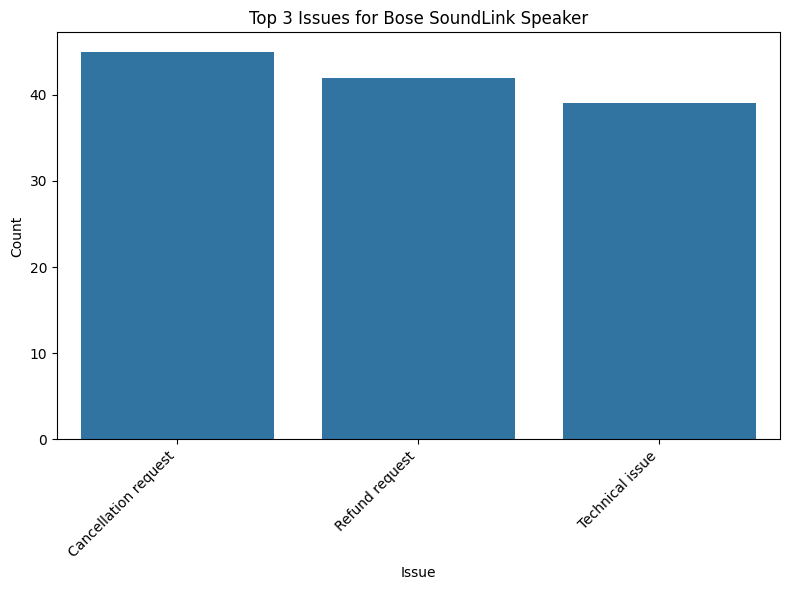

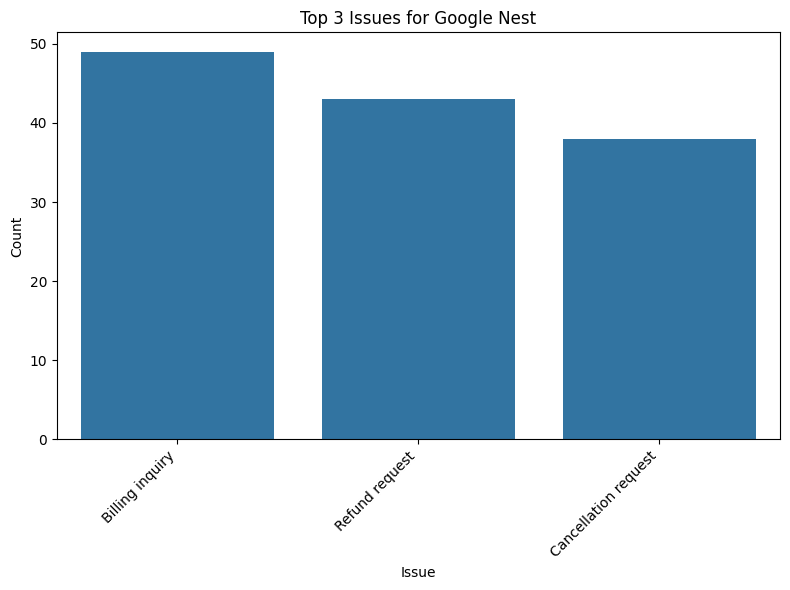

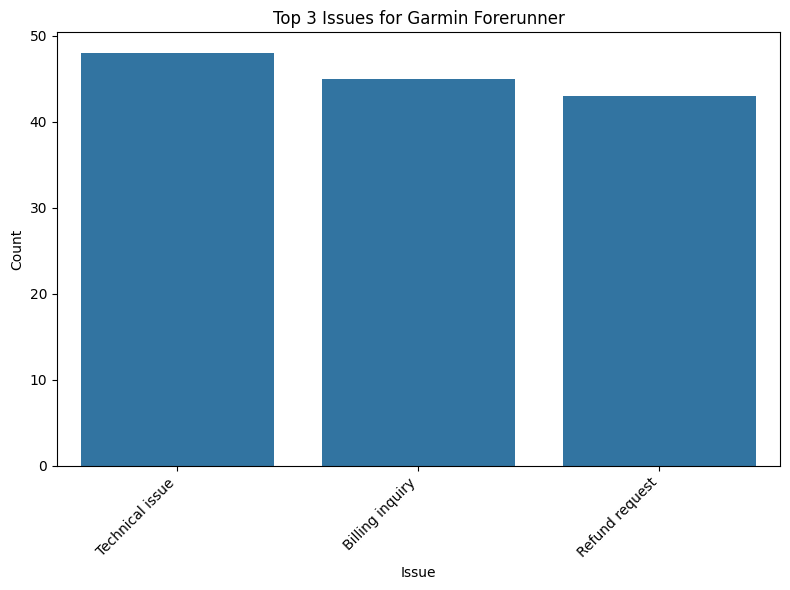

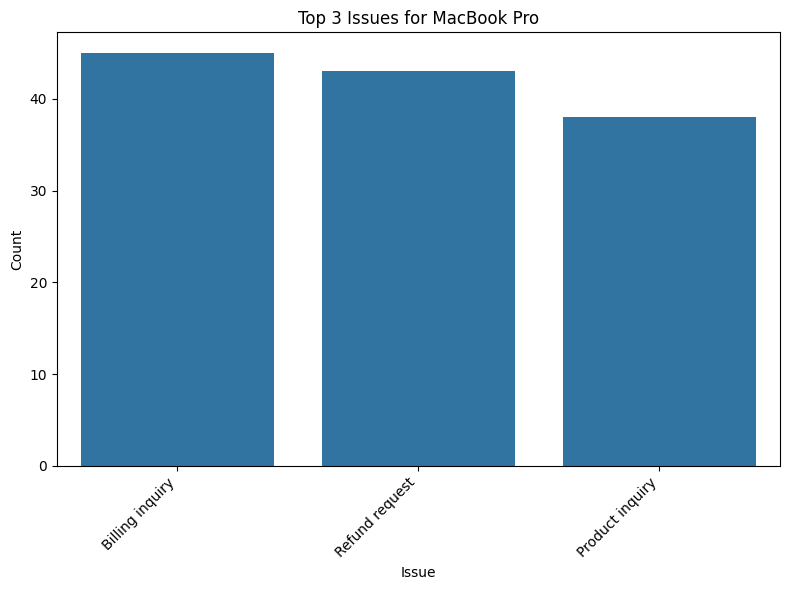

In [11]:
# prompt: for every product, make value count bar chart for top 3 issues that that product has

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is already loaded as in the previous code
# df = pd.read_csv("customer_support_tickets.csv")

def plot_top_issues(product):
    product_df = df[df['Product Purchased'] == product]
    top_issues = product_df['Ticket Type'].value_counts().nlargest(3)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_issues.index, y=top_issues.values)
    plt.title(f'Top 3 Issues for {product}')
    plt.xlabel('Issue')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.show()


# Get unique products
products = df['Product Purchased'].unique()

for product in products:
    plot_top_issues(product)

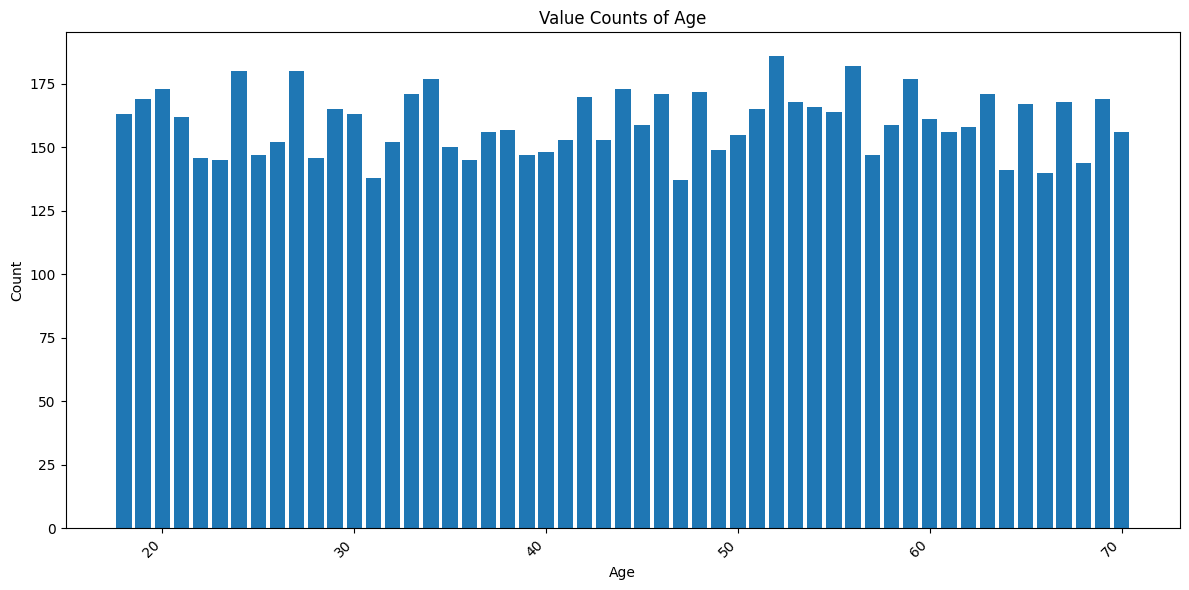

In [12]:
# prompt: value count bar chart for age, sorted by age on x axis

import pandas as pd
import matplotlib.pyplot as plt
# Assuming you've already loaded the dataframe 'df' as shown in the previous code.
# If not, run the previous code first.
df = pd.read_csv("customer_support_tickets.csv")

# Value counts of 'Age'
age_counts = df['Customer Age'].value_counts().sort_index()

# Create the bar chart
plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
plt.bar(age_counts.index, age_counts.values)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Value Counts of Age")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability if needed
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Age Group
[0, 10)      [Billing inquiry, Cancellation request, Produc...
[10, 20)     [Product inquiry, Refund request, Billing inqu...
[20, 30)     [Refund request, Cancellation request, Billing...
[30, 40)     [Technical issue, Cancellation request, Refund...
[40, 50)     [Technical issue, Product inquiry, Billing inq...
[50, 60)     [Technical issue, Refund request, Cancellation...
[60, 70)     [Refund request, Billing inquiry, Cancellation...
[70, 80)     [Cancellation request, Product inquiry, Refund...
[80, 90)     [Billing inquiry, Cancellation request, Produc...
[90, 100)    [Billing inquiry, Cancellation request, Produc...
dtype: object


C:\Users\kdp46\AppData\Local\Temp\ipykernel_7784\1498437876.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  issue_counts = df.groupby(['Age Group', 'Ticket Type'])['Ticket Type'].count().unstack()


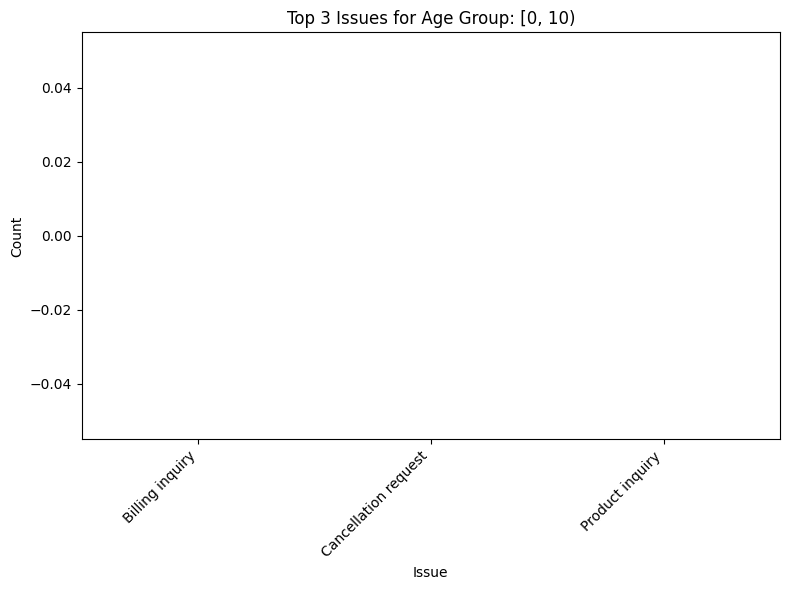

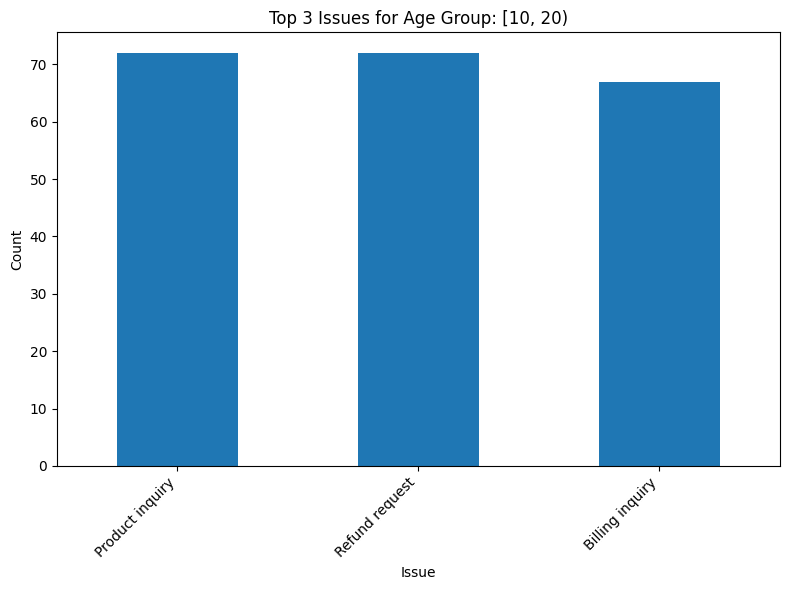

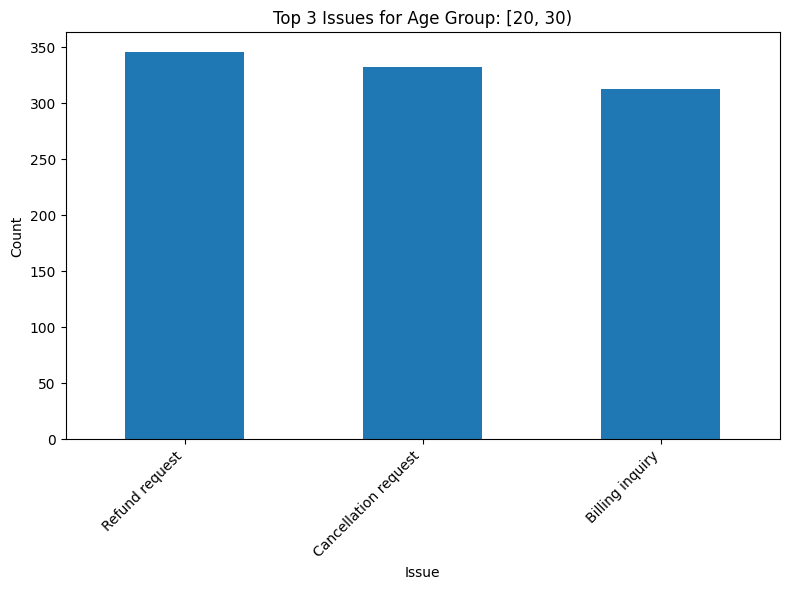

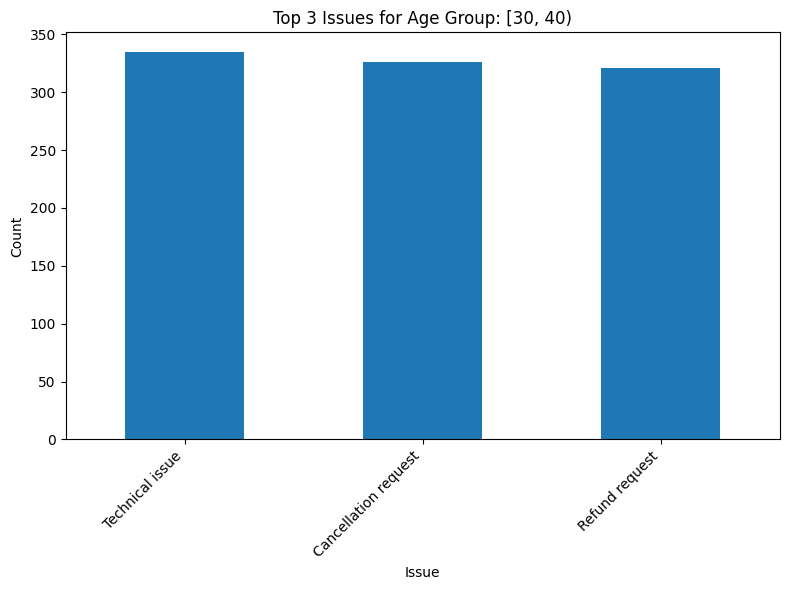

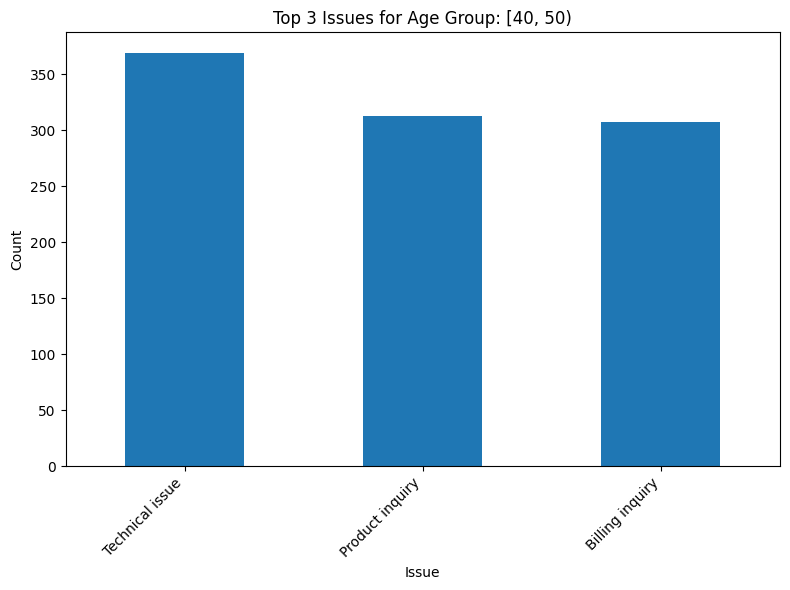

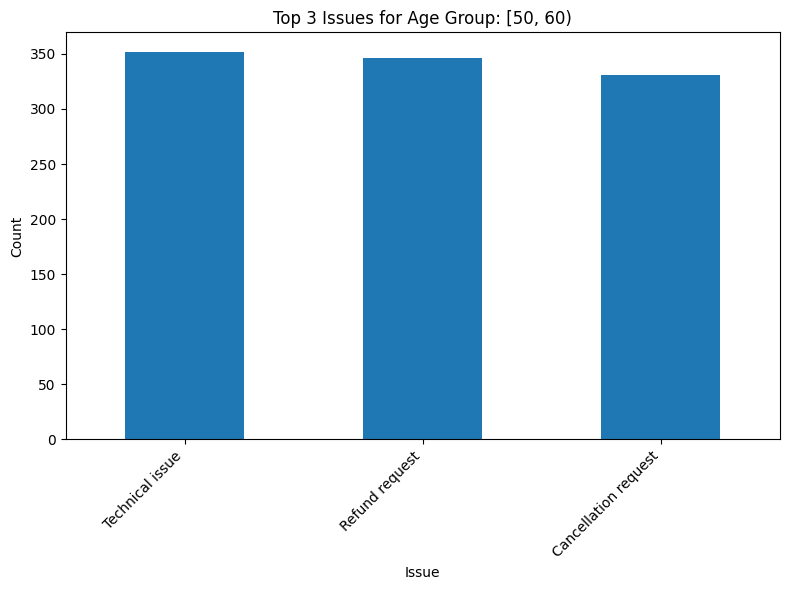

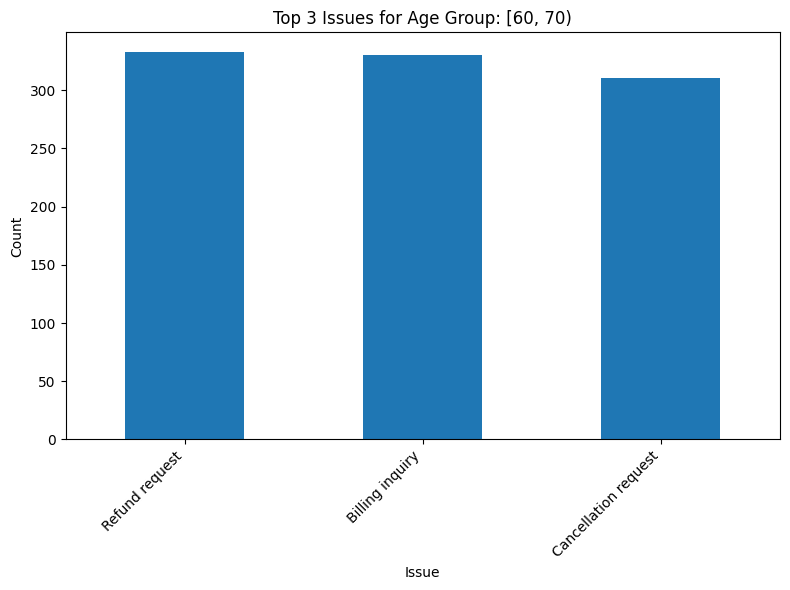

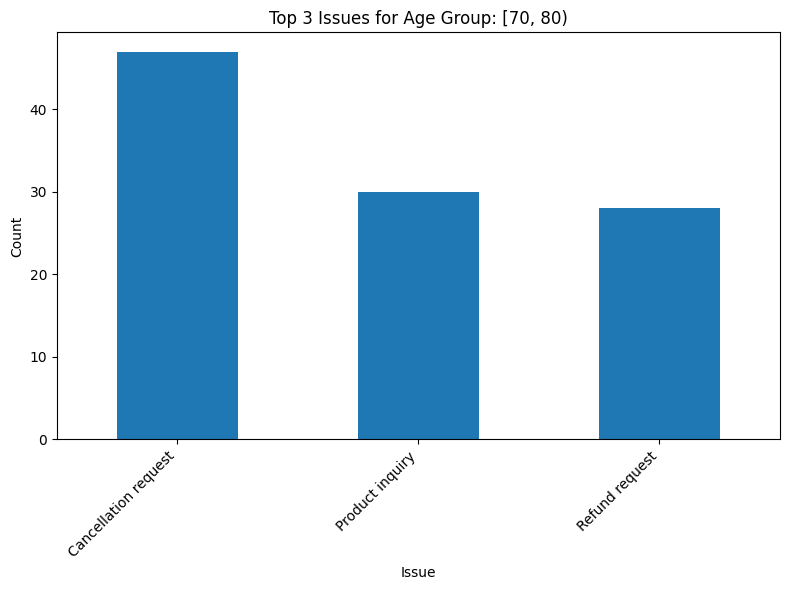

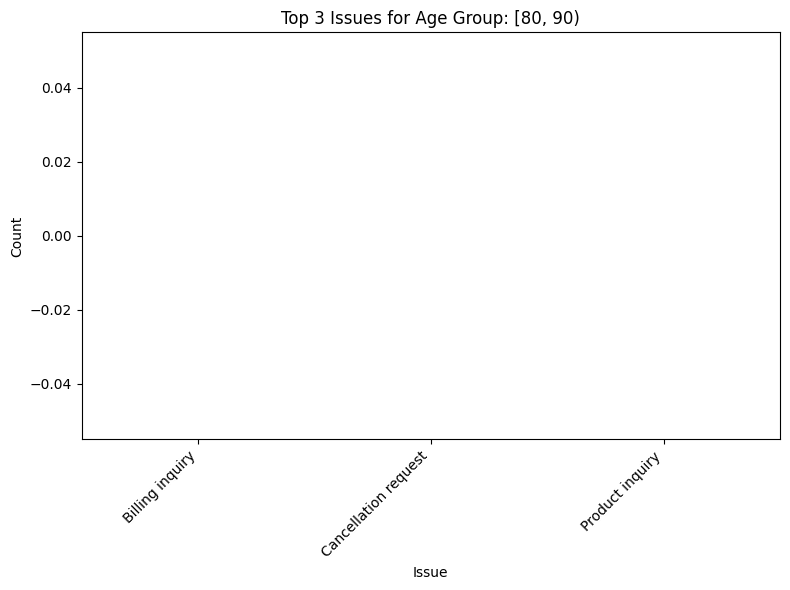

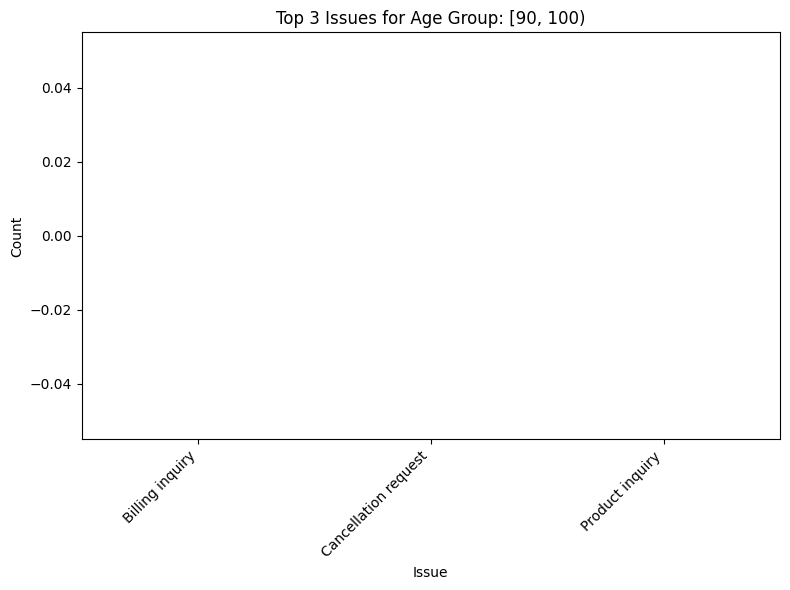

In [13]:
# Product Purchased
# prompt: top 3 issues by counts for every age group in bins of 10 years

import pandas as pd
import matplotlib.pyplot as plt

# Create age bins
df['Age Group'] = pd.cut(df['Customer Age'], bins=range(0, 101, 10), right=False)

# Group by age group and issue, then count occurrences
issue_counts = df.groupby(['Age Group', 'Ticket Type'])['Ticket Type'].count().unstack()

# Find the top 3 issues for each age group
top_3_issues = issue_counts.apply(lambda x: x.nlargest(3).index.tolist(), axis=1)

# Print the result
print(top_3_issues)


# Plotting (optional):  Visualize top 3 issues for each age group
for age_group, issues in top_3_issues.items():
    counts = issue_counts.loc[age_group][issues]
    plt.figure(figsize=(8, 6))
    counts.plot(kind='bar')
    plt.title(f'Top 3 Issues for Age Group: {age_group}')
    plt.xlabel('Issue')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Age Group
[0, 10)          [Adobe Photoshop, Amazon Echo, Amazon Kindle]
[10, 20)             [Philips Hue Lights, iPhone, LG Smart TV]
[20, 30)     [Amazon Echo, Dyson Vacuum Cleaner, Microsoft ...
[30, 40)            [GoPro Hero, LG Smart TV, Nest Thermostat]
[40, 50)     [LG OLED, Philips Hue Lights, Roomba Robot Vac...
[50, 60)     [GoPro Hero, Apple AirPods, Bose SoundLink Spe...
[60, 70)        [Sony Xperia, Lenovo ThinkPad, Sony 4K HDR TV]
[70, 80)     [Sony Xperia, Canon DSLR Camera, Nest Thermostat]
[80, 90)         [Adobe Photoshop, Amazon Echo, Amazon Kindle]
[90, 100)        [Adobe Photoshop, Amazon Echo, Amazon Kindle]
dtype: object


C:\Users\kdp46\AppData\Local\Temp\ipykernel_7784\2720017168.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  issue_counts = df.groupby(['Age Group', 'Product Purchased'])['Product Purchased'].count().unstack()


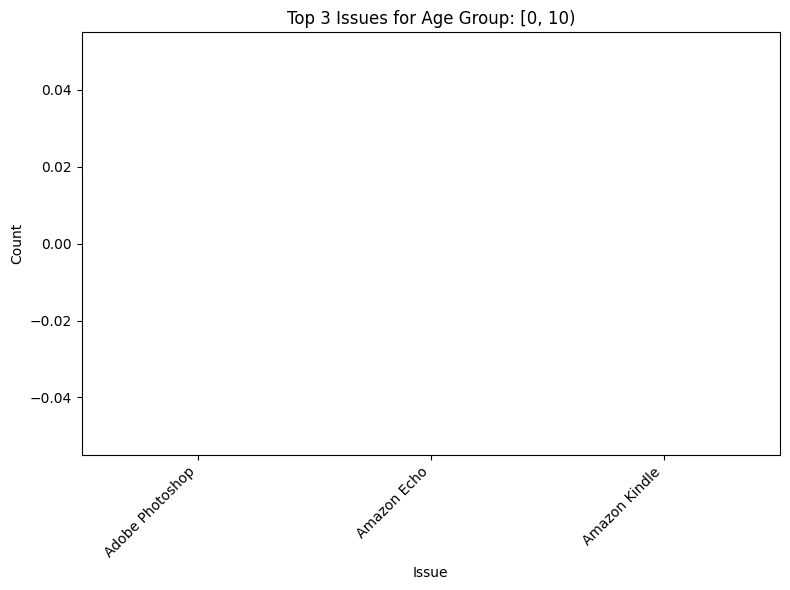

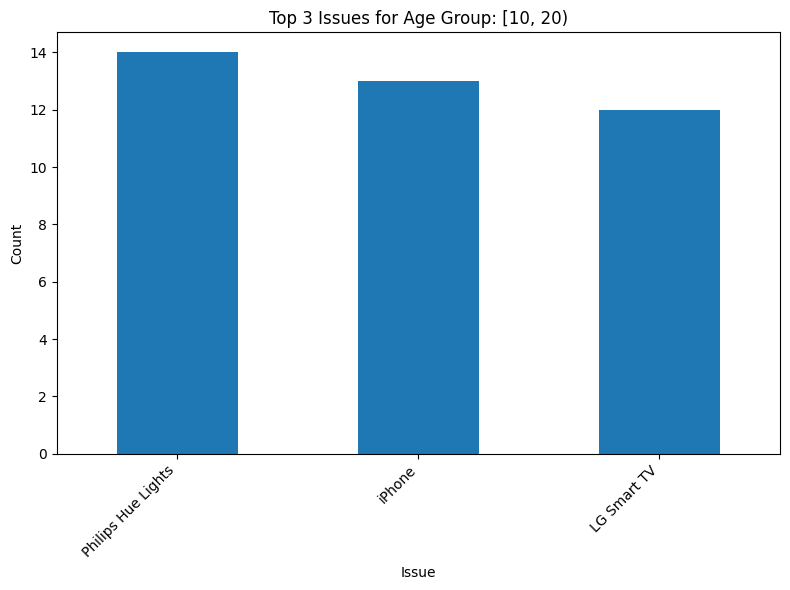

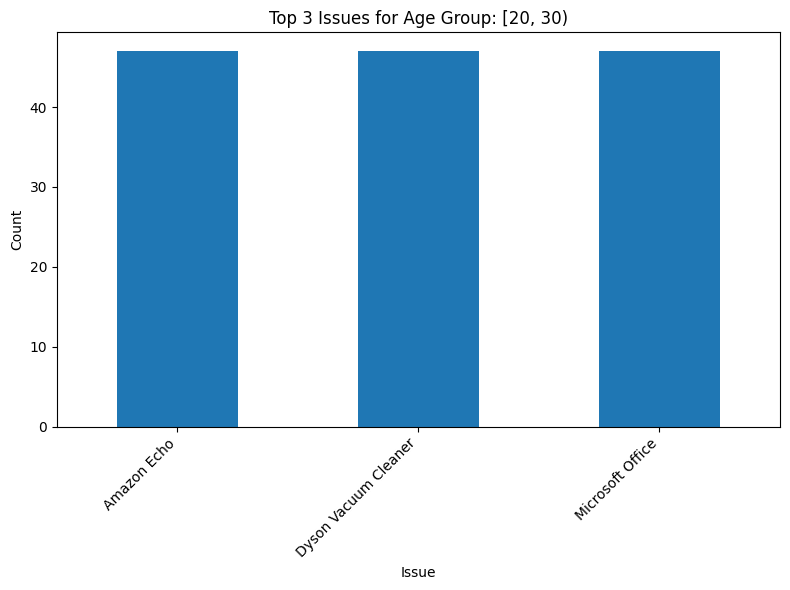

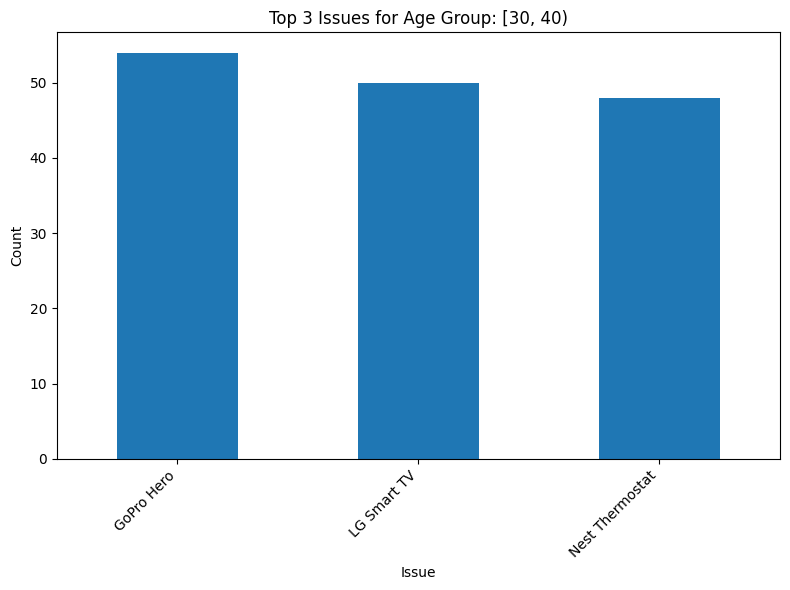

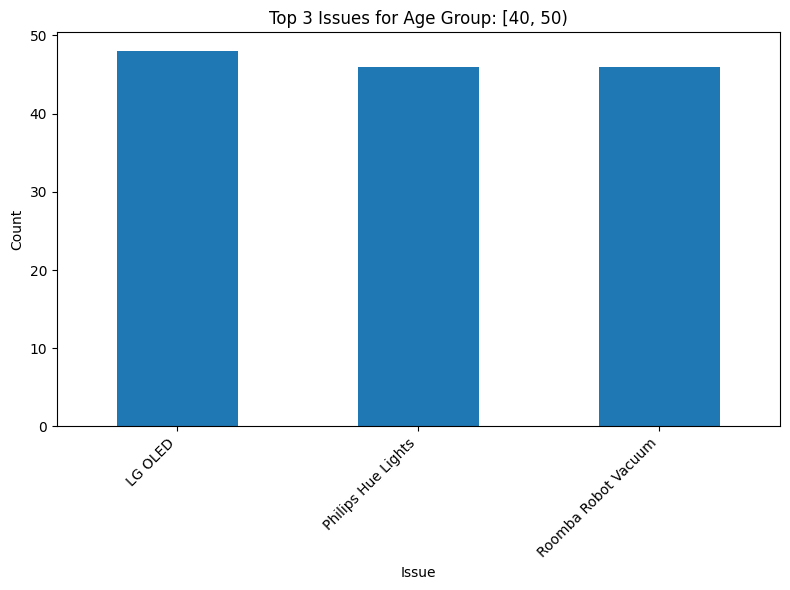

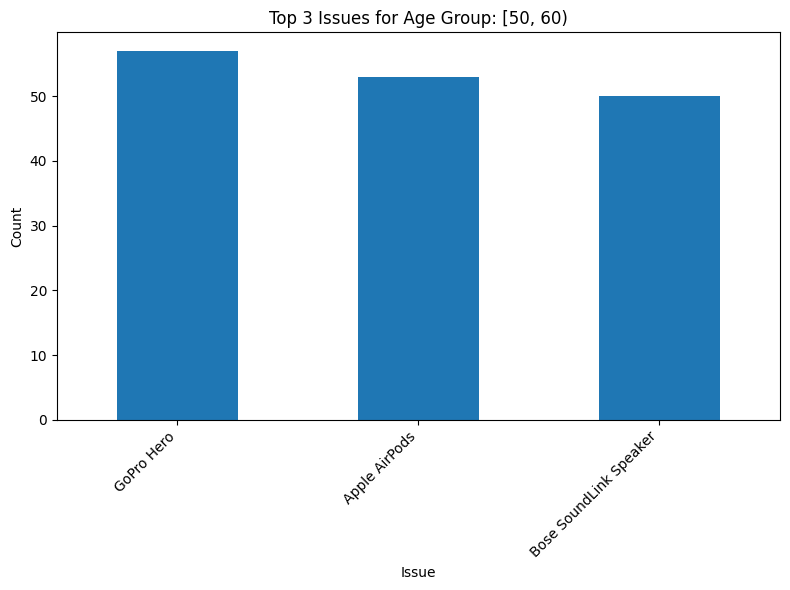

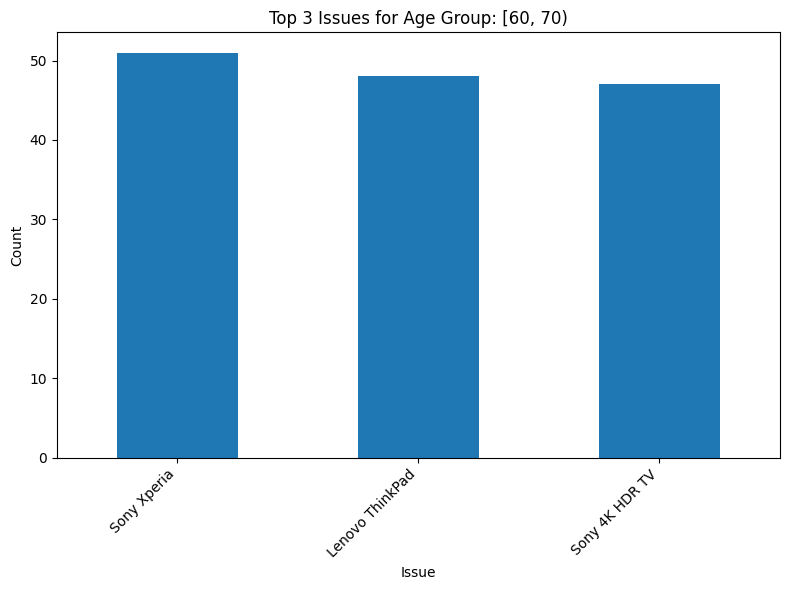

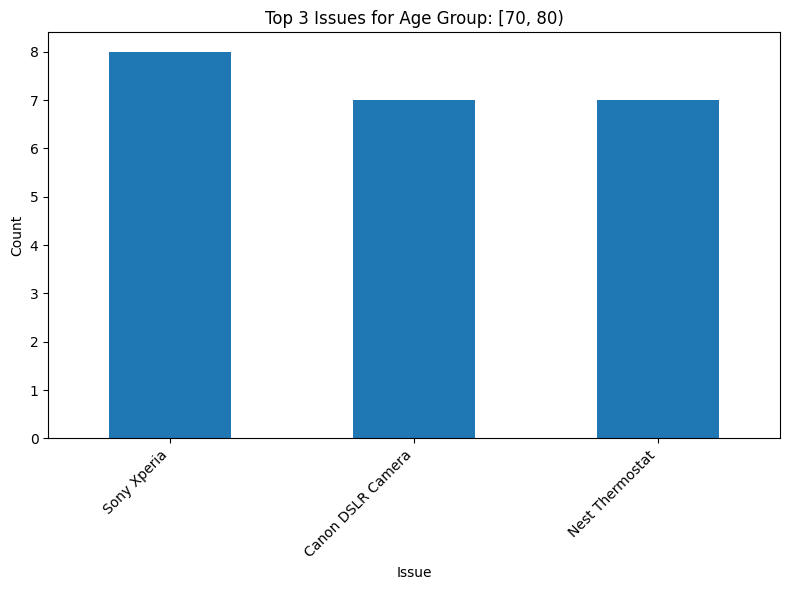

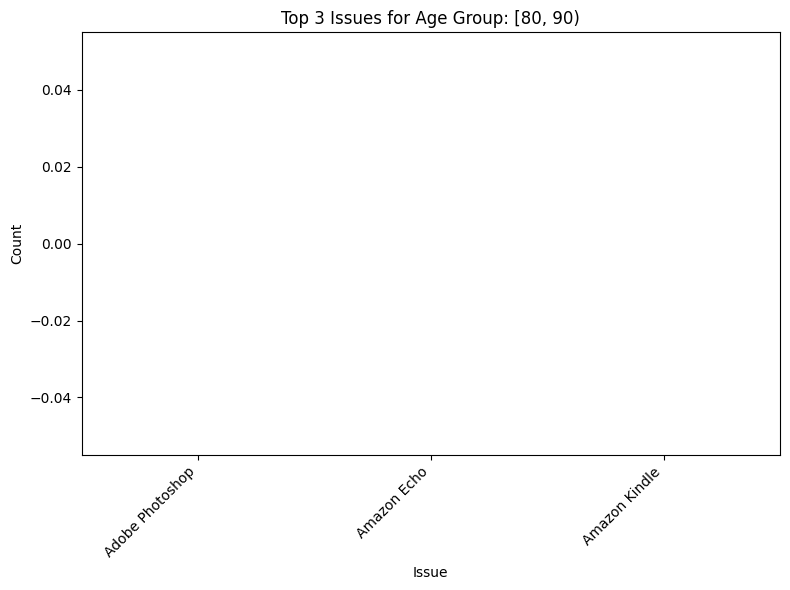

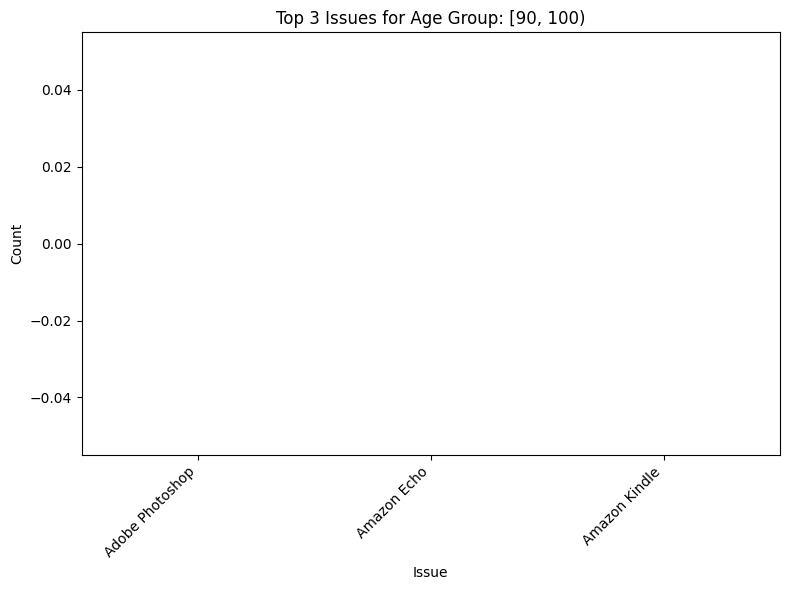

In [14]:
# prompt: top 3 issues by counts for every age group in bins of 10 years

import pandas as pd
import matplotlib.pyplot as plt

# Create age bins
df['Age Group'] = pd.cut(df['Customer Age'], bins=range(0, 101, 10), right=False)

# Group by age group and issue, then count occurrences
issue_counts = df.groupby(['Age Group', 'Product Purchased'])['Product Purchased'].count().unstack()

# Find the top 3 issues for each age group
top_3_issues = issue_counts.apply(lambda x: x.nlargest(3).index.tolist(), axis=1)

# Print the result
print(top_3_issues)


# Plotting (optional):  Visualize top 3 issues for each age group
for age_group, issues in top_3_issues.items():
    counts = issue_counts.loc[age_group][issues]
    plt.figure(figsize=(8, 6))
    counts.plot(kind='bar')
    plt.title(f'Top 3 Issues for Age Group: {age_group}')
    plt.xlabel('Issue')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [15]:
df["Ticket Type"].unique()

array(['Technical issue', 'Billing inquiry', 'Cancellation request',
       'Product inquiry', 'Refund request'], dtype=object)

In [16]:
df["Ticket Priority"].unique()

array(['Critical', 'Low', 'High', 'Medium'], dtype=object)

In [17]:
df["Ticket Subject"].unique()

array(['Product setup', 'Peripheral compatibility', 'Network problem',
       'Account access', 'Data loss', 'Payment issue', 'Refund request',
       'Battery life', 'Installation support', 'Software bug',
       'Hardware issue', 'Product recommendation', 'Delivery problem',
       'Display issue', 'Cancellation request', 'Product compatibility'],
      dtype=object)

In [18]:
df["Ticket Channel"].unique()

array(['Social media', 'Chat', 'Email', 'Phone'], dtype=object)

In [19]:
df["Ticket Status"].unique()

array(['Pending Customer Response', 'Closed', 'Open'], dtype=object)

Batches:   0%|          | 0/265 [00:00<?, ?it/s]

Batches:   0%|          | 0/265 [00:00<?, ?it/s]

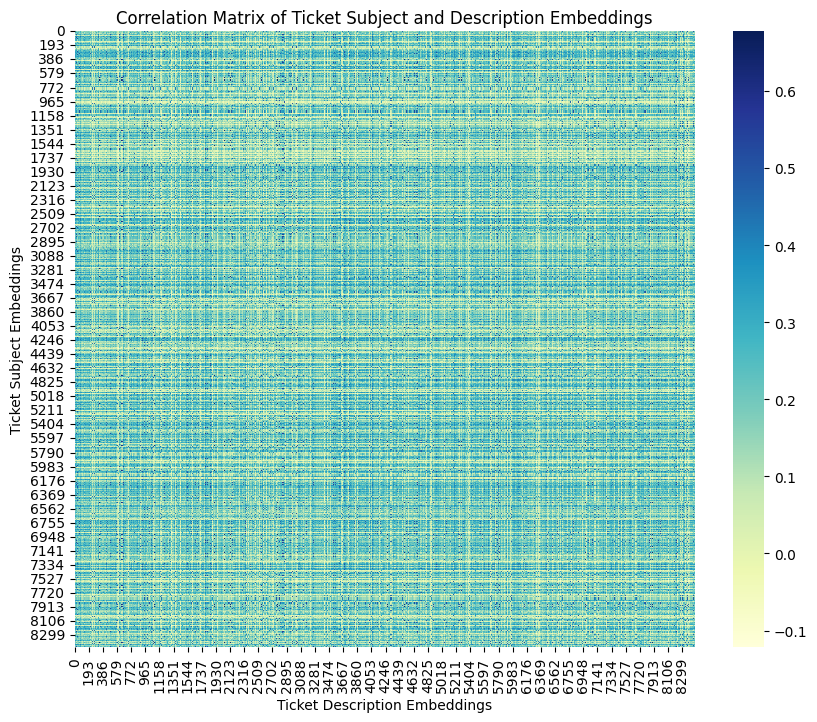

In [20]:
# prompt: "Ticket Subject", "Ticket Description" make an embedding of strings and make a correlatioin matrix heat map, use GUSE model

!pip install sentence-transformers

import pandas as pd
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (assuming customer_support_tickets.csv is in the current directory)
df = pd.read_csv("customer_support_tickets.csv")

# Select the relevant columns
text_data = df[["Ticket Subject", "Ticket Description"]]

# Initialize the GUSE model
model = SentenceTransformer('all-mpnet-base-v2') # Using a strong general-purpose model

# Generate embeddings for the "Ticket Subject" and "Ticket Description"
subject_embeddings = model.encode(df["Ticket Subject"].tolist(), batch_size=32, show_progress_bar=True)
description_embeddings = model.encode(df["Ticket Description"].tolist(), batch_size=32, show_progress_bar=True)


# Calculate cosine similarity between embeddings
correlation_matrix = util.cos_sim(subject_embeddings, description_embeddings)

# Convert the similarity matrix to a DataFrame for visualization
correlation_df = pd.DataFrame(correlation_matrix.numpy())

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_df, cmap="YlGnBu")
plt.title("Correlation Matrix of Ticket Subject and Description Embeddings")
plt.xlabel("Ticket Description Embeddings")
plt.ylabel("Ticket Subject Embeddings")
plt.show()

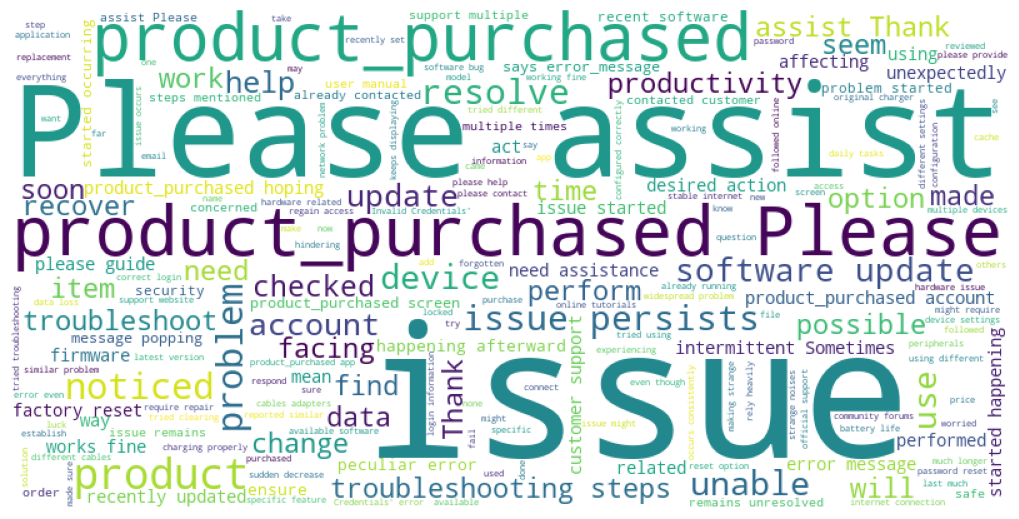

In [21]:
# prompt: "Ticket Description" word cloud

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Combine all ticket descriptions into a single string
text = " ".join(df["Ticket Description"].astype(str))

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=STOPWORDS).generate(text)

# Display the generated image:
plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [22]:
df["Ticket Description"][100]

"I'm having an issue with the {product_purchased}. Please assist. I'm using what is on my phone right now. I also have an issue with a product that was sold out of style, not due to an oversize. I've tried clearing the cache and data for the {product_purchased} app, but the issue persists."

In [23]:
# bank-complaints analysis

df = pd.read_csv("complaints.csv")
df.head(20)

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...
5,5,credit_reporting,payment history missing credit report made mis...
6,6,credit_reporting,va date complaint experian credit bureau invol...
7,7,credit_reporting,account reported abbreviated name full name se...
8,8,credit_reporting,account reported abbreviated name full name se...
9,9,credit_reporting,usdoexxxx account reported abbreviated name fu...


In [24]:
df["product"].value_counts()

product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64

In [25]:
df.loc[df["product"].eq("credit_reporting"), :]

,Unnamed: 0,product,narrative
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...
5,5,credit_reporting,payment history missing credit report made mis...
6,6,credit_reporting,va date complaint experian credit bureau invol...
7,7,credit_reporting,account reported abbreviated name full name se...
...,...,...,...
162403,162403,credit_reporting,response unsatisfactory go right fair credit r...
162405,162405,credit_reporting,system allow upload many file prior compliant ...
162406,162406,credit_reporting,system allow upload many file prior compliant ...
162410,162410,credit_reporting,zales comenity bank closed sold account report...


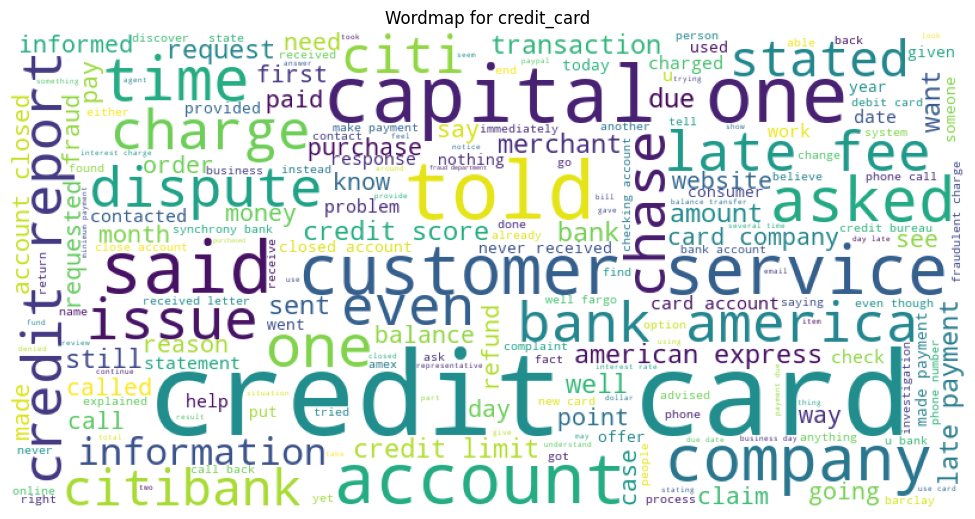

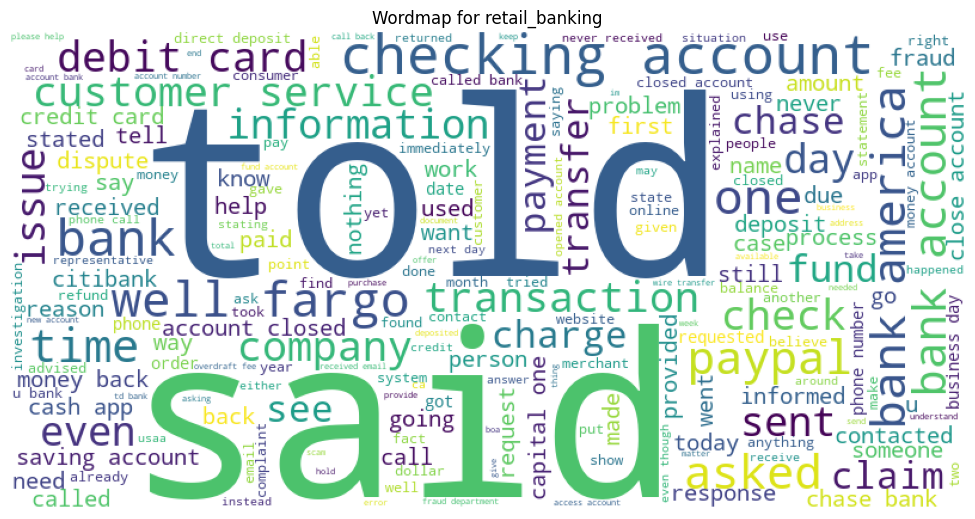

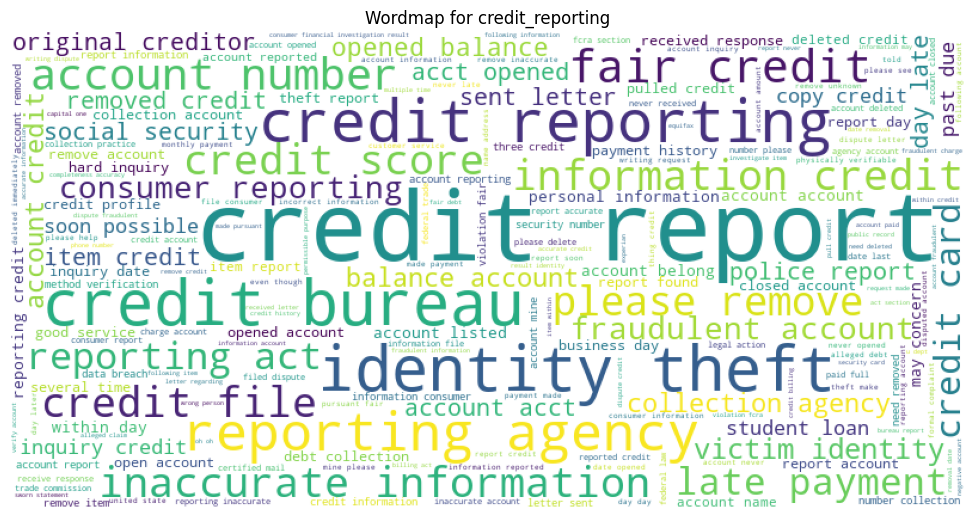

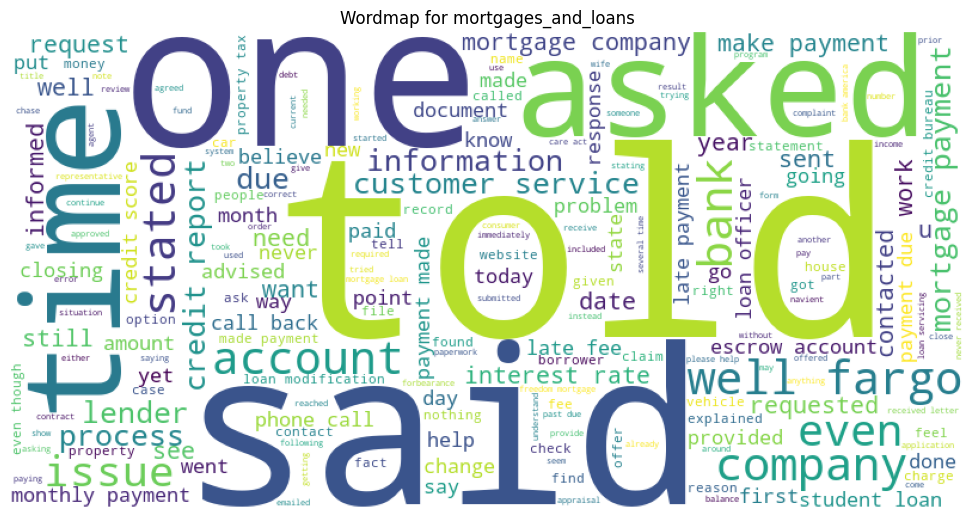

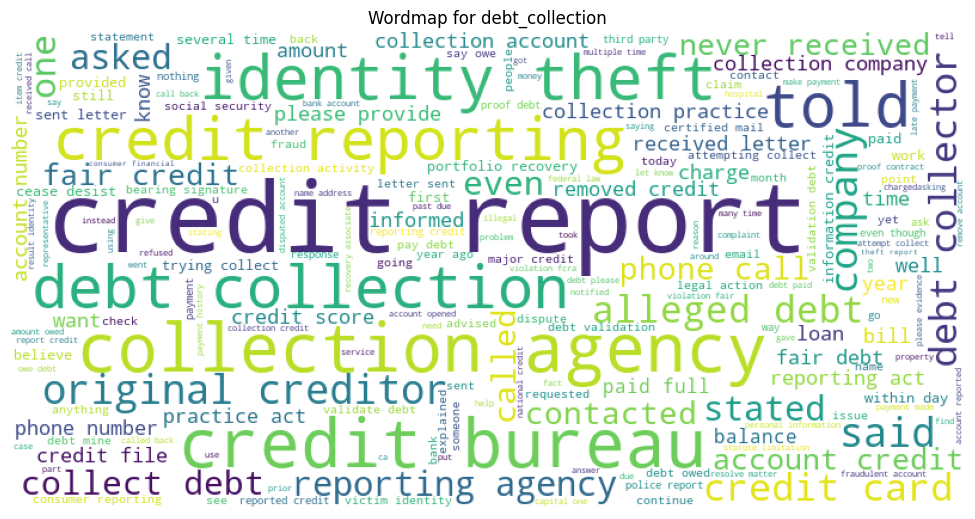

In [26]:
# prompt: create word maps for different products

import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame loaded from 'complaints.csv'
# df = pd.read_csv("complaints.csv")

def create_wordmap(product):
    # Filter DataFrame for the specified product
    product_df = df[df["product"] == product]

    # Combine all consumer complaint narratives for the product
    text = " ".join(product_df["narrative"].astype(str))

    # Create and generate a word cloud image:
    wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=STOPWORDS).generate(text)

    # Display the generated image:
    plt.figure(figsize=(10, 5), facecolor=None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(f"Wordmap for {product}")  # Added title for clarity
    plt.tight_layout(pad=0)
    plt.show()

# Example usage (replace with your actual product names):
products_to_analyze = df["product"].unique()

for product in products_to_analyze:
    create_wordmap(product)

In [27]:
# prompt: for every product, find top occuring words, phrases (max 3 word phrase) from narrative, not word cloud, just print
# print single word top list first, then 2 word top list, and then 3

import pandas as pd
from collections import Counter

# Assuming 'df' is your DataFrame loaded from 'complaints.csv'
# df = pd.read_csv("complaints.csv")

def top_occurring_words(product, n=10):
    product_df = df[df["product"] == product]
    text = " ".join(product_df["narrative"].astype(str)).lower()
    words = text.split()
    word_counts = Counter(words)
    return word_counts.most_common(n)

def top_occurring_phrases(product, n=10):
  product_df = df[df["product"] == product]
  text = " ".join(product_df["narrative"].astype(str)).lower()
  words = text.split()
  phrases = []
  for i in range(len(words) - 1):
    phrases.append(words[i] + " " + words[i+1])
  for i in range(len(words) - 2):
    phrases.append(words[i] + " " + words[i+1] + " " + words[i+2])
  phrase_counts = Counter(phrases)
  return phrase_counts.most_common(n)


products_to_analyze = df["product"].unique()

for product in products_to_analyze:
    print(f"Top words for {product}:")
    for word, count in top_occurring_words(product):
        print(f"- {word}: {count}")

    print(f"\nTop 2-word phrases for {product}:")
    for phrase, count in top_occurring_phrases(product):
        if len(phrase.split()) == 2:
            print(f"- {phrase}: {count}")

    print(f"\nTop 3-word phrases for {product}:")
    for phrase, count in top_occurring_phrases(product):
        if len(phrase.split()) == 3:
            print(f"- {phrase}: {count}")
    print("-" * 20)

Top words for credit_card:
- card: 37861
- credit: 33268
- account: 28506
- payment: 17876
- bank: 14078
- charge: 13869
- would: 13002
- time: 12595
- one: 11316
- received: 10273

Top 2-word phrases for credit_card:
- credit card: 13647
- capital one: 5010
- customer service: 3726
- credit report: 2445
- bank america: 2394
- late fee: 2351
- american express: 1974
- credit score: 1895
- credit limit: 1790
- late payment: 1718

Top 3-word phrases for credit_card:
--------------------
Top words for retail_banking:
- account: 45472
- bank: 26096
- money: 15977
- would: 10500
- day: 9942
- told: 9681
- check: 9313
- fund: 9162
- time: 8675
- transaction: 8135

Top 2-word phrases for retail_banking:
- checking account: 4175
- well fargo: 3292
- bank america: 3167
- bank account: 2821
- customer service: 2420
- debit card: 2379
- saving account: 1713
- money back: 1503
- cash app: 1463
- account closed: 1431

Top 3-word phrases for retail_banking:
--------------------
Top words for credit_

In [28]:
val = df.loc[df["product"].eq("credit_reporting"), :]["narrative"].map(lambda x: "identity theft" in x.lower() if type(x) == str else False)

In [29]:
df.loc[df["product"].eq("credit_reporting"), :].loc[val]["narrative"].values

array(['anyone us credit report another consumer report deny credit must tell give name address phone number agency provided right dispute inaccurate incomplete information right know credit score public assistance applied fha rehabilitation home loan sent original document lending business told front receive ssi let know front law state fha k rehabilitation home loan credit worthiness checked rent payment utility bill showing payment history able make repayment time also nc able account used qualified housing expense summit funding nc complaint nmls id assistant summit funding credit worthiness require determination applicant ability willingness meet debt obligation ability income availability reliability ability willingness pay critical credit worthiness approval filling discrimination suit already fraud alert report filed complaint separate case prior unethical real estate business practice stealing guilty identity theft identity fraud xxxxs nc complaint case ref took half year clea

In [30]:
### ADDING ESCALATION DATASET

In [31]:
""" 
import pickle

!wget https://zenodo.org/records/4383145/files/feature_matrix.pickle?download=1

#ren "feature_matrix.pickle@download=1" feature_matrix.pickle
# 'ren' for windows and 'mv' for linux

import os

old_name = "feature_matrix.pickle?download=1"
new_name = "feature_matrix.pickle"

if os.path.exists(old_name):  # Check if the file exists
    os.rename(old_name, new_name)
    print(f"Renamed '{old_name}' to '{new_name}'")
else:
    print(f"File '{old_name}' not found!")
"""

import os

# Define the expected file name
expected_file = "feature_matrix.pickle"
downloaded_file = "feature_matrix.pickle?download=1"

# Download the file (platform-independent)
try:
    import urllib.request
    url = "https://zenodo.org/records/4383145/files/feature_matrix.pickle?download=1"
    print("Downloading file...")
    urllib.request.urlretrieve(url, expected_file)
    print(f"File downloaded as: {expected_file}")
except Exception as e:
    print(f"Error downloading file: {e}")

# Rename if necessary
if os.path.exists(downloaded_file):
    os.rename(downloaded_file, expected_file)
    print(f"Renamed '{downloaded_file}' to '{expected_file}'")

# Check if the file exists and is valid
if os.path.exists(expected_file):
    print("Download successful!")
    print(f"File size: {os.path.getsize(expected_file)} bytes")
else:
    print("Download failed!")


File downloaded as: feature_matrix.pickle
Download successful!
File size: 274286272 bytes


In [32]:
import pickle

with open("feature_matrix.pickle", "rb") as f:
    feature_matrix = pickle.load(f)
feature_matrix

,customer,pred_time,log_f1_w_00,log_f5_w_00,log_f7_w_00,log_f9_w_00,log_f10_w_00,log_f11_w_00,log_f12_w_00,log_f13_w_00,...,log_f14_w_09,log_f14_w_08,log_f14_w_07,log_f14_w_06,log_f14_w_05,log_f14_w_04,log_f14_w_03,log_f14_w_02,log_f14_w_01,log_f14_w_00
0,Customer_0,1996-13,1.0,10,7,10,4,2,19.0,10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Customer_0,1996-14,0.0,10,7,10,7,1,2.0,9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Customer_0,1996-15,0.0,11,7,11,2,3,0.0,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Customer_0,1996-16,0.0,11,7,11,3,4,0.0,11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Customer_0,1996-17,0.0,13,7,13,1,7,0.0,15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106377,Customer_2167,1998-09,0.0,0,0,0,0,0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106378,Customer_2167,1998-10,0.0,0,0,0,0,0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106379,Customer_2167,1998-11,0.0,0,0,0,0,0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106380,Customer_2167,1998-12,0.0,0,0,0,0,0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
## Microsoft +Endava
# all_tickets.csv
# https://www.kaggle.com/code/aniketg11/support-tickets-classification/input

In [34]:
import pandas as pd
df = pd.read_csv("all_tickets.csv")
df.head()

,title,body,ticket_type,category,sub_category1,sub_category2,business_service,urgency,impact
0,NaN,hi since recruiter lead permission approve req...,1,4,2,21,71,3,4
1,connection with icon,icon dear please setup icon per icon engineers...,1,6,22,7,26,3,4
2,work experience user,work experience user hi work experience studen...,1,5,13,7,32,3,4
3,requesting for meeting,requesting meeting hi please help follow equip...,1,5,13,7,32,3,4
4,reset passwords for external accounts,re expire days hi ask help update passwords co...,1,4,2,76,4,3,4


In [35]:
df = df.loc[df["category"].isin([4, 5, 6]), :]

In [36]:
df["title"].nunique(), df["body"].nunique()

(29034, 46323)

In [37]:
df["category"].unique()

array([4, 6, 5])

In [38]:
df["category"].value_counts()

category
4    34061
5     9634
6     2628
Name: count, dtype: int64

In [39]:
df["ticket_type"].unique()

array([1, 0])

In [40]:
df["impact"].unique()

array([4, 3, 2, 0, 1])

In [41]:
df["urgency"].unique()

array([3, 0, 1, 2])

In [42]:
df.head()

,title,body,ticket_type,category,sub_category1,sub_category2,business_service,urgency,impact
0,NaN,hi since recruiter lead permission approve req...,1,4,2,21,71,3,4
1,connection with icon,icon dear please setup icon per icon engineers...,1,6,22,7,26,3,4
2,work experience user,work experience user hi work experience studen...,1,5,13,7,32,3,4
3,requesting for meeting,requesting meeting hi please help follow equip...,1,5,13,7,32,3,4
4,reset passwords for external accounts,re expire days hi ask help update passwords co...,1,4,2,76,4,3,4


In [43]:
df["sub_category1"].nunique(), df["sub_category2"].nunique()

(23, 61)

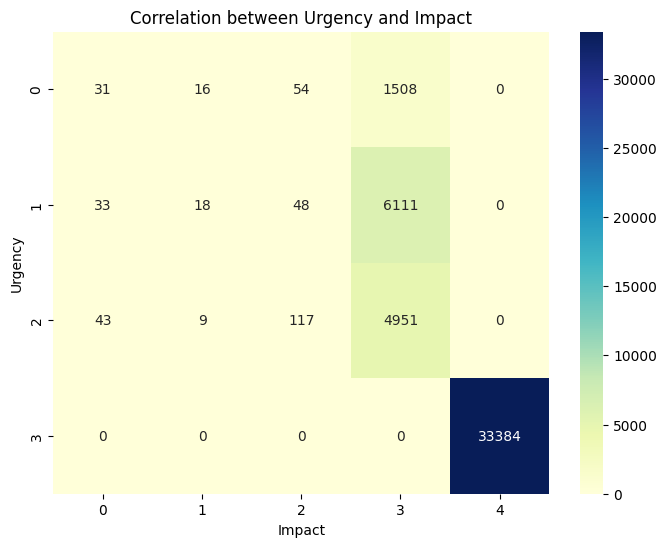

In [44]:
# prompt: what is the correlatation between urgency and impact, make a heat map
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame is named 'df' and has been loaded from "all_tickets.csv"
# and filtered as shown in the provided code.  If not, load and filter it first.

# Create a cross-tabulation of urgency and impact
urgency_impact_counts = pd.crosstab(df['urgency'], df['impact'])

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(urgency_impact_counts, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Correlation between Urgency and Impact')
plt.xlabel('Impact')
plt.ylabel('Urgency')
plt.show()

In [45]:
# prompt: give random samples from 1. impact: 3 and urgency: 1; 2. impact: 3 and urgency: 0 from the above dataset

import pandas as pd

# Assuming your DataFrame is named 'df' and has been loaded from "all_tickets.csv"
# and filtered as shown in the provided code.  If not, load and filter it first.
# Example:
# df = pd.read_csv("all_tickets.csv")
# df = df.loc[df["category"].isin([4, 5, 6]), :]

# Sample with impact=3 and urgency=1
sample1 = df[(df["impact"] == 3) & (df["urgency"] == 1)].sample(n=10)  # Adjust n for desired sample size

# Sample with impact=3 and urgency=0
sample2 = df[(df["impact"] == 3) & (df["urgency"] == 0)].sample(n=10) # Adjust n for desired sample size


print("Sample 1 (impact=3, urgency=1):")
print(sample1.loc[:, ["title", "body"]].to_dict(orient='records'))

print("\nSample 2 (impact=3, urgency=0):")
print(sample2.loc[:, ["title", "body"]].to_dict(orient='records'))

Sample 1 (impact=3, urgency=1):
[{'title': 'outlook constantly asking for credentials', 'body': 'sent tuesday july problem with hello have problem connecting when connect get up enter password when enter correct password for entering password still shows up writing web kind regards'}, {'title': 'possibly infected hardware', 'body': 'link la la dup ca virus edited sa incident'}, {'title': 'are not updated as approved', 'body': 'sent updated approved hello kindly asking your assistance with below issue please let know if anything needed thank you kind regards data entry sent updated approved hello could you please check why update approved even though line manager approved them already last approved thanks analyst'}, {'title': 'sync issues with', 'body': 'sent monday sync issues with hello please log non request assign queue for below directory sync thank you best regards senior engineer en'}, {'title': 'submitting error', 'body': 'sent tuesday problem hello can submit tried different wa

In [46]:
df.loc[df["urgency"].eq(3), :]

,title,body,ticket_type,category,sub_category1,sub_category2,business_service,urgency,impact
0,NaN,hi since recruiter lead permission approve req...,1,4,2,21,71,3,4
1,connection with icon,icon dear please setup icon per icon engineers...,1,6,22,7,26,3,4
2,work experience user,work experience user hi work experience studen...,1,5,13,7,32,3,4
3,requesting for meeting,requesting meeting hi please help follow equip...,1,5,13,7,32,3,4
4,reset passwords for external accounts,re expire days hi ask help update passwords co...,1,4,2,76,4,3,4
...,...,...,...,...,...,...,...,...,...
34613,adjustment,adjustment hi please help rectify working subm...,1,4,1,7,35,3,4
34614,new interns for bulk am,friday july re bulk starter form interns hi gu...,1,4,2,94,87,3,4
34617,direct dial request,users whom number,1,4,3,7,87,3,4
34619,amend tasks for project,friday july code hi please make changes tasks ...,1,4,3,7,35,3,4


In [47]:
# prompt: get 20 random examples for all ticket types and print only title and body, give list of dicts for all categories

import pandas as pd

# Assuming 'df' is your DataFrame loaded from 'all_tickets.csv'
# and the necessary preprocessing steps have been performed.

def get_random_examples(df, num_examples=10):
    """
    Gets a specified number of random examples for each ticket type.
    """
    all_examples = []

    for ticket_type in df["category"].unique():
        type_df = df[df["category"] == ticket_type]
        random_samples = type_df.sample(min(num_examples, len(type_df))) # Ensures you don't try to sample more rows than exist.
        for index, row in random_samples.iterrows():
          all_examples.append({"title": row['title'], "body": row['body'], "category": row["category"]})

    return all_examples

# Example usage:
random_examples = get_random_examples(df)

# Print only title and body for each example
# for example in random_examples:
#     print("Title:", example['title'])
#     print("Body:", example['body'])
#     print("-" * 20)

# List of dictionaries for each category
random_examples

[{'title': 'oracle access required',
  'body': 'thursday required hi please thanks analyst wednesday pm re required approved side please kind regards wednesday pm required hi please module please reference same accesses best regards',
  'category': 4},
 {'title': 'access bit bucket',
  'body': 'friday pm bit bucket hello please bit bucket more please let',
  'category': 4},
 {'title': 'oracle not working',
  'body': 'sent tuesday working hello can log lets access site but than get following error whatever trying what can about thank you',
  'category': 4},
 {'title': 'outlook via issue',
  'body': 'sent friday via issue dear look like have problems for via application keeps asking for credentials does connect server please investigate thank you regards',
  'category': 4},
 {'title': 'dial outside phone number',
  'body': 'tuesday pm dial phone number hi possible phone dial phone number phone number thanks senior',
  'category': 4},
 {'title': 'wants to access information security',
  '

In [10]:
#Multi-Lingual Support Data
# https://www.kaggle.com/datasets/tobiasbueck/multilingual-customer-support-tickets

In [8]:
import pandas as pd

# Load the multilingual customer support tickets dataset
df = pd.read_csv("helpdesk_customer_tickets.csv")
df.head()

,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9
0,Problema crítico del servidor requiere atenció...,Es necesaria una investigación inmediata sobre...,Estamos investigando urgentemente el problema ...,Incident,Technical Support,high,es,IT Services,Urgent Issue,Service Disruption,Incident Report,Service Recovery,System Maintenance,NaN,NaN,NaN,NaN
1,Anfrage zur Verfügbarkeit des Dell XPS 13 9310,"Sehr geehrter Kundenservice,\n\nich hoffe, die...","Sehr geehrter <name>,\n\nvielen Dank, dass Sie...",Request,Customer Service,low,de,Tech Online Store,Sales Inquiry,Product Support,Customer Service,Order Issue,Returns and Exchanges,NaN,NaN,NaN,NaN
2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es...","Prezado <name>,\n\nObrigado por entrar em cont...",Incident,Technical Support,high,pt,IT Services,Technical Support,Software Bug,Problem Resolution,Urgent Issue,IT Support,NaN,NaN,NaN,NaN
3,Urgent Assistance Required: AWS Service,"Dear IT Services Support Team, \n\nI am reachi...","Dear <name>,\n\nThank you for reaching out reg...",Request,IT Support,high,en,IT Services,IT Support,Urgent Issue,Service Notification,Cloud Services,Problem Resolution,Technical Guidance,Performance Tuning,NaN,NaN
4,Problème d'affichage de MacBook Air,Cher équipe de support du magasin en ligne Tec...,"Cher <name>,\n\nMerci de nous avoir contactés ...",Incident,Product Support,low,fr,Tech Online Store,Technical Support,Product Support,Hardware Failure,Service Recovery,Routine Request,NaN,NaN,NaN,NaN


In [6]:
# Summary statistics for numerical and categorical columns
df.describe(include='all')

,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9
count,3533,3999,4000,4000,4000,4000,4000,4000,4000,4000,4000,3999,3363,2181,1045,269,0.0
unique,3533,3999,4000,4,10,3,5,9,42,61,73,102,94,89,72,53,NaN
top,Problema crítico del servidor requiere atenció...,Es necesaria una investigación inmediata sobre...,Estamos investigando urgentemente el problema ...,Incident,Technical Support,high,en,IT Services,Technical Support,Product Support,Urgent Issue,Problem Resolution,Problem Resolution,Problem Resolution,Service Recovery,Technical Guidance,NaN
freq,1,1,1,1608,1317,1649,1391,1716,2126,1091,420,1089,802,420,131,33,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Identify all columns that contain 'tag' in their name
tag_columns = [col for col in df.columns if 'tag' in col.lower()]

# Combine all tag columns into one long series
all_tags_series = pd.concat([df[col] for col in tag_columns], ignore_index=True)

# Drop missing values and get unique tags
unique_tags = all_tags_series.dropna().unique()

# Show total and some sample unique tags
print(f"Total unique tags: {len(unique_tags)}")
print("Sample unique tags:", unique_tags[:10])

Total unique tags: 213
Sample unique tags: ['Urgent Issue' 'Sales Inquiry' 'Technical Support' 'IT Support'
 'Billing Issue' 'Service Outage' 'Network Issue' 'Customer Service'
 'Product Support' 'Software Bug']


In [20]:
print("Queues:\n", df["queue"].unique())
print("\nBusiness types:\n", df["business_type"].unique())
print("\nLanguages:\n", df["language"].unique())

Queues:
 ['Technical Support' 'Customer Service' 'IT Support' 'Product Support'
 'Billing and Payments' 'Service Outages and Maintenance'
 'General Inquiry' 'Returns and Exchanges' 'Sales and Pre-Sales'
 'Human Resources']

Business types:
 ['IT Services' 'Tech Online Store' 'IT Consulting Firm' 'Online Store'
 'Software Development Company' 'Pit Services' 'Adobe Photoshop 2024'
 '_IT_Services_' 'IT Consulting Service']

Languages:
 ['es' 'de' 'pt' 'en' 'fr']


In [16]:
print("Ticket types:\n", df["type"].value_counts())
print("\nTicket priorities:\n", df["priority"].value_counts())

Ticket types:
 type
Incident    1608
Request     1097
Problem      853
Change       442
Name: count, dtype: int64

Ticket priorities:
 priority
high      1649
medium    1603
low        748
Name: count, dtype: int64


In [22]:
incident_priority_counts = df.loc[df["type"] == "Incident", "priority"].value_counts()
print("Priority distribution for 'Incident' tickets:\n", incident_priority_counts)

Priority distribution for 'Incident' tickets:
 priority
high      769
medium    591
low       248
Name: count, dtype: int64


In [24]:
low_priority_tickets = df[df["priority"] == "low"]
print(f"Total low priority tickets: {len(low_priority_tickets)}")
low_priority_tickets.head()

Total low priority tickets: 748


,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9
1,Anfrage zur Verfügbarkeit des Dell XPS 13 9310,"Sehr geehrter Kundenservice,\n\nich hoffe, die...","Sehr geehrter <name>,\n\nvielen Dank, dass Sie...",Request,Customer Service,low,de,Tech Online Store,Sales Inquiry,Product Support,Customer Service,Order Issue,Returns and Exchanges,NaN,NaN,NaN,NaN
4,Problème d'affichage de MacBook Air,Cher équipe de support du magasin en ligne Tec...,"Cher <name>,\n\nMerci de nous avoir contactés ...",Incident,Product Support,low,fr,Tech Online Store,Technical Support,Product Support,Hardware Failure,Service Recovery,Routine Request,NaN,NaN,NaN,NaN
6,Discrepancia de facturación en Google Workspace,"Estimado equipo de soporte de TI,\n\nEstoy esc...","Estimado <name>,\n\nGracias por ponerte en con...",Incident,Billing and Payments,low,es,IT Services,Billing Issue,Account Assistance,Payment Processing,Customer Service,Problem Resolution,NaN,NaN,NaN,NaN
17,Hilfestellung für die Integration von Google W...,"Sehr geehrtes Kundenserviceteam,\n\nich hoffe,...","Sehr geehrte/r <name>,\n\nvielen Dank, dass Si...",Request,Technical Support,low,de,IT Services,Technical Support,IT Support,Product Support,Technical Guidance,Software Bug,Documentation Request,General Inquiry,NaN,NaN
19,Assistance Needed for Chrome Crashes,"Dear Tech Online Store Customer Support, I am ...","Dear <name>,\n\nThank you for contacting Tech ...",Problem,Technical Support,low,en,Tech Online Store,Technical Support,Software Bug,Problem Resolution,Customer Service,NaN,NaN,NaN,NaN,NaN
